In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [3]:
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("application_train.csv")

In [5]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
df.tail()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
307510,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,0,0,0,0,0.0,0.0,0.0,2.0,0.0,1.0


In [7]:
df.shape

(307511, 122)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [9]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [10]:
df.describe(include='object')

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,WEEKDAY_APPR_PROCESS_START,ORGANIZATION_TYPE,FONDKAPREMONT_MODE,HOUSETYPE_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE
count,307511,307511,307511,307511,306219,307511,307511,307511,307511,211120,307511,307511,97216,153214,151170,161756
unique,2,3,2,2,7,8,5,6,6,18,7,58,4,3,7,2
top,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,Laborers,TUESDAY,Business Entity Type 3,reg oper account,block of flats,Panel,No
freq,278232,202448,202924,213312,248526,158774,218391,196432,272868,55186,53901,67992,73830,150503,66040,159428


In [11]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

# Dataset EDA Overview

This notebook performs the initial exploratory analysis of the Home Credit Default Risk dataset.

Objective:
--> Understand dataset structure
--> Identify data types
--> Prepare for advanced EDA

In [12]:
df.isnull().sum()

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64

## EDA Data Profiling

In [13]:
num_cols = df.select_dtypes(include=['float64','int64']).columns
cat_cols = df.select_dtypes(include='object').columns

In [14]:
print('Numerical Columns :',len(num_cols))
print('Categorycal Columns :',len(cat_cols))

Numerical Columns : 106
Categorycal Columns : 16


In [15]:
num_cols

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=106)

In [16]:
cat_cols

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')

In [17]:
df.isnull().sum()

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64

In [18]:
missing = df.isnull().sum()

missing = missing[missing>0]

missing.sort_values(ascending=False)

COMMONAREA_MEDI             214865
COMMONAREA_MODE             214865
COMMONAREA_AVG              214865
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_MEDI    213514
                             ...  
EXT_SOURCE_2                   660
AMT_GOODS_PRICE                278
AMT_ANNUITY                     12
CNT_FAM_MEMBERS                  2
DAYS_LAST_PHONE_CHANGE           1
Length: 67, dtype: int64

In [19]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent = missing_percent[missing_percent>0]

missing_percent.sort_values(ascending=False)

COMMONAREA_MEDI             69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_AVG              69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
                              ...    
EXT_SOURCE_2                 0.214626
AMT_GOODS_PRICE              0.090403
AMT_ANNUITY                  0.003902
CNT_FAM_MEMBERS              0.000650
DAYS_LAST_PHONE_CHANGE       0.000325
Length: 67, dtype: float64

In [20]:
missing_df = pd.DataFrame({
    'missing values': df.isnull().sum(),
    'percentage' : (df.isnull().sum()/len(df))*100
})

missing_df = missing_df[missing_df['missing values']>0]
missing_df.sort_values(by='percentage',ascending=False)

,missing values,percentage
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
...,...,...
EXT_SOURCE_2,660,0.214626
AMT_GOODS_PRICE,278,0.090403
AMT_ANNUITY,12,0.003902
CNT_FAM_MEMBERS,2,0.000650


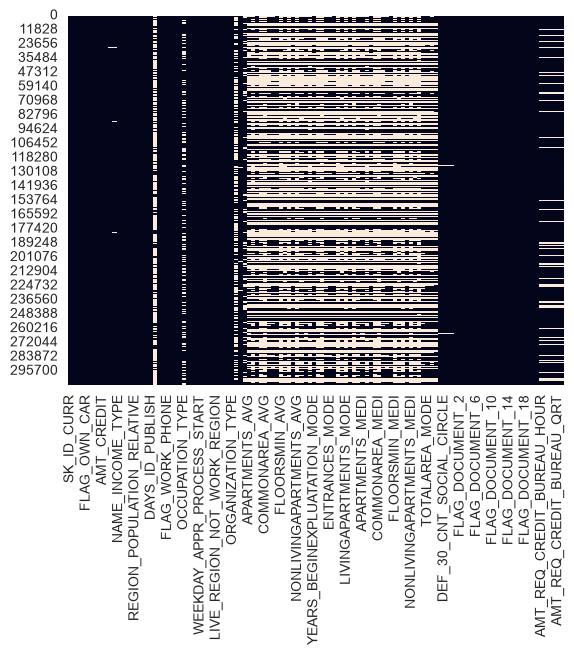

In [21]:
sns.heatmap(df.isnull(),cbar=False)
plt.show()

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df.nunique()

SK_ID_CURR                    307511
TARGET                             2
NAME_CONTRACT_TYPE                 2
CODE_GENDER                        3
FLAG_OWN_CAR                       2
                               ...  
AMT_REQ_CREDIT_BUREAU_DAY          9
AMT_REQ_CREDIT_BUREAU_WEEK         9
AMT_REQ_CREDIT_BUREAU_MON         24
AMT_REQ_CREDIT_BUREAU_QRT         11
AMT_REQ_CREDIT_BUREAU_YEAR        25
Length: 122, dtype: int64

In [24]:
df.nunique().sort_values(ascending=False)

SK_ID_CURR           307511
EXT_SOURCE_2         119831
EXT_SOURCE_1         114584
DAYS_BIRTH            17460
DAYS_REGISTRATION     15688
                      ...  
FLAG_DOCUMENT_16          2
FLAG_DOCUMENT_15          2
FLAG_DOCUMENT_14          2
FLAG_DOCUMENT_20          2
FLAG_DOCUMENT_21          2
Length: 122, dtype: int64

In [25]:
# constant columns

constant = []

for col in df.columns:
    if df[col].nunique()==1:
        constant.append(col)

constant

[]

Constant columns

-->> If this column has only one unique value, then it is a constant column
-->> This dataset no constant columns so give empty list

In [26]:
df.dtypes.value_counts()

float64    65
int64      41
object     16
Name: count, dtype: int64

In [27]:
df.memory_usage(deep=True)

Index                              132
SK_ID_CURR                     2460088
TARGET                         2460088
NAME_CONTRACT_TYPE            18289544
CODE_GENDER                   15375558
                                ...   
AMT_REQ_CREDIT_BUREAU_DAY      2460088
AMT_REQ_CREDIT_BUREAU_WEEK     2460088
AMT_REQ_CREDIT_BUREAU_MON      2460088
AMT_REQ_CREDIT_BUREAU_QRT      2460088
AMT_REQ_CREDIT_BUREAU_YEAR     2460088
Length: 123, dtype: int64

Find columns using a lot of memory.
Improve the model perfomance.

In [28]:
#total memory bytes

df.memory_usage(deep=True).sum()

np.int64(529515493)

In [29]:
# bytes to MB

df.memory_usage(deep=True).sum()/1024**2

np.float64(504.98532581329346)

# Data Query Report

In [30]:
data_profile = pd.DataFrame({
    'Column':       df.columns,
    'Data Type':    df.dtypes.values,
    'Missing values': df.isnull().sum().values,
    'Missing Percentage': round(df.isnull().sum()/len(df)*100,2).values,
    'Unique Values': df.nunique().values
})

data_profile.head()

,Column,Data Type,Missing values,Missing Percentage,Unique Values
0,SK_ID_CURR,int64,0,0.0,307511
1,TARGET,int64,0,0.0,2
2,NAME_CONTRACT_TYPE,object,0,0.0,2
3,CODE_GENDER,object,0,0.0,3
4,FLAG_OWN_CAR,object,0,0.0,2


In [31]:
def recommendation(row):

    if row["Missing Percentage"] > 50:
        return "Consider Dropping"

    elif row["Missing Percentage"] > 0:
        return "Imputation Required"

    elif row["Unique Values"] == 1:
        return "Drop Constant Feature"

    else:
        return "Keep"

data_profile["Recommendation"] = data_profile.apply(recommendation, axis=1)

data_profile.head()

,Column,Data Type,Missing values,Missing Percentage,Unique Values,Recommendation
0,SK_ID_CURR,int64,0,0.0,307511,Keep
1,TARGET,int64,0,0.0,2,Keep
2,NAME_CONTRACT_TYPE,object,0,0.0,2,Keep
3,CODE_GENDER,object,0,0.0,3,Keep
4,FLAG_OWN_CAR,object,0,0.0,2,Keep


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [33]:
df["TARGET"].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [34]:
round(df["TARGET"].value_counts(normalize=True)*100*2)

TARGET
0    184.0
1     16.0
Name: proportion, dtype: float64

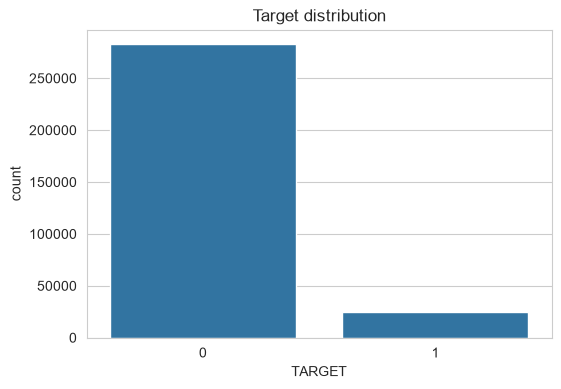

In [35]:
plt.figure(figsize=(6,4))

sns.countplot(x="TARGET",data=df)

plt.title("Target distribution")

plt.show()

The dataset is highly imbalanced.

In [36]:
print(f"Total Features:{df.shape[1]}")

print(f"Numerical Features: {len(num_cols)}")

print(f"Categorical Features: {len(cat_cols)}")

Total Features:122
Numerical Features: 106
Categorical Features: 16


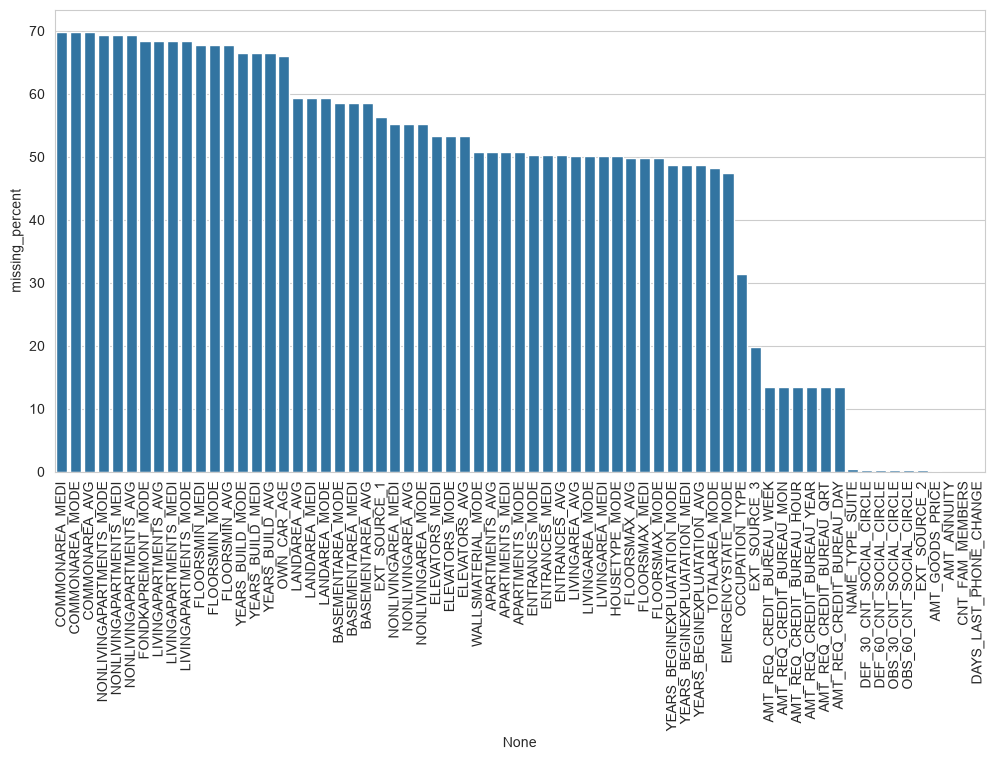

In [37]:
missing_df = missing_df.sort_values(by="percentage",ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(
    x=missing_df.index,
    y=missing_df["percentage"]
)

plt.xticks(rotation=90)

plt.ylabel("missing_percent")
plt.show()

Several columns contain a high percentage of missing values.

Instead of immediately dropping them, we will first evaluate their business importance.

Features with meaningful financial information will be imputed, while low-value columns with excessive missing values may be removed after detailed analysis.

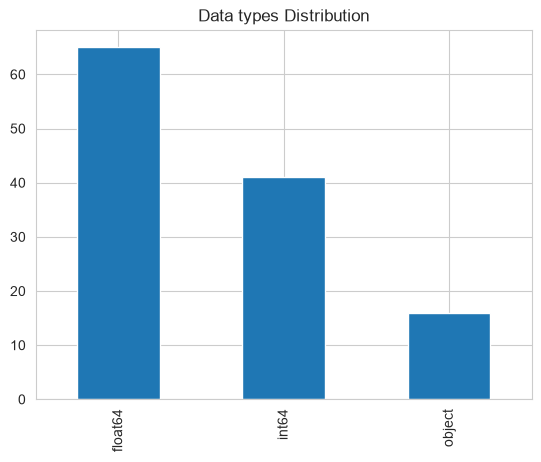

In [38]:
df.dtypes.value_counts().plot(
    kind="bar"
)

plt.title("Data types Distribution")
plt.show()

In [39]:
data_profile.to_csv(
    "../reports/data_profile_report.csv",
    index=False
)

# Feature Analysis

--> Target Distribution

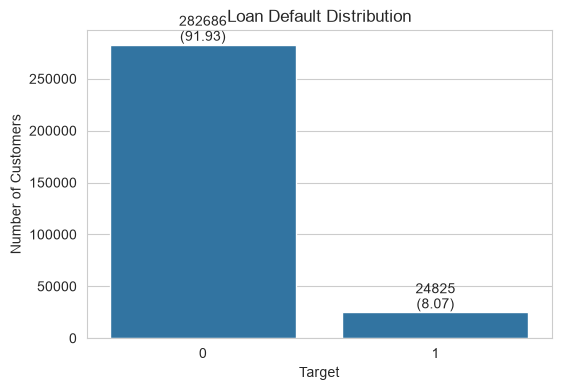

In [40]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x="TARGET",data=df)

total = len(df)

for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total
    ax.annotate(f"{count}\n({percentage:.2f})",
                (p.get_x()+p.get_width()/2,p.get_height()),
                ha="center",
                va="bottom",
                fontsize=10)
plt.title("Loan Default Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Customers")

plt.show()

Observation:

• The dataset is highly imbalanced.
• Around 92% of customers successfully repaid their loans.
• Around 8% of customers defaulted.

Business Impact:

Using Accuracy alone would be misleading.
The model should focus on identifying risky customers while minimizing false approvals.

In [41]:
num_summary = df[num_cols].describe().T

num_summary

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


In [42]:
num_summary["Missing Percentage"] = round(df[num_cols].isnull().sum()/len(df)*100,2)

num_summary.head()

,count,mean,std,min,25%,50%,75%,max,Missing Percentage
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0,0.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0,0.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0,0.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0,0.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0,0.0


In [43]:
cat_summary = pd.DataFrame({
    "Unique":df[cat_cols].nunique(),
    "Missing percentage" : round(df[cat_cols].isnull().sum()/len(df)*100,2)
})

cat_summary

,Unique,Missing percentage
NAME_CONTRACT_TYPE,2,0.00
CODE_GENDER,3,0.00
FLAG_OWN_CAR,2,0.00
FLAG_OWN_REALTY,2,0.00
NAME_TYPE_SUITE,7,0.42
NAME_INCOME_TYPE,8,0.00
NAME_EDUCATION_TYPE,5,0.00
NAME_FAMILY_STATUS,6,0.00
NAME_HOUSING_TYPE,6,0.00
OCCUPATION_TYPE,18,31.35


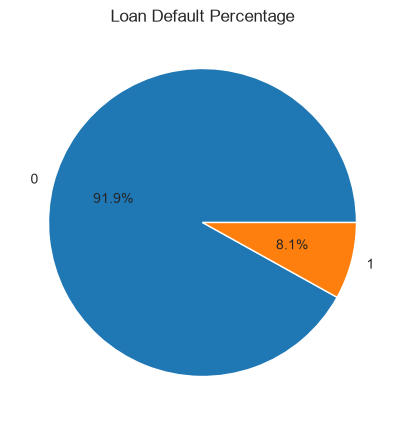

In [44]:
plt.figure(figsize=(5,5))

df["TARGET"].value_counts().plot(
    kind="pie",
    autopct='%1.1f%%'
)
plt.ylabel("")
plt.title("Loan Default Percentage")
plt.show()

In [45]:
high_missing = missing_df[
    missing_df["percentage"]>40
]

high_missing

,missing values,percentage
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


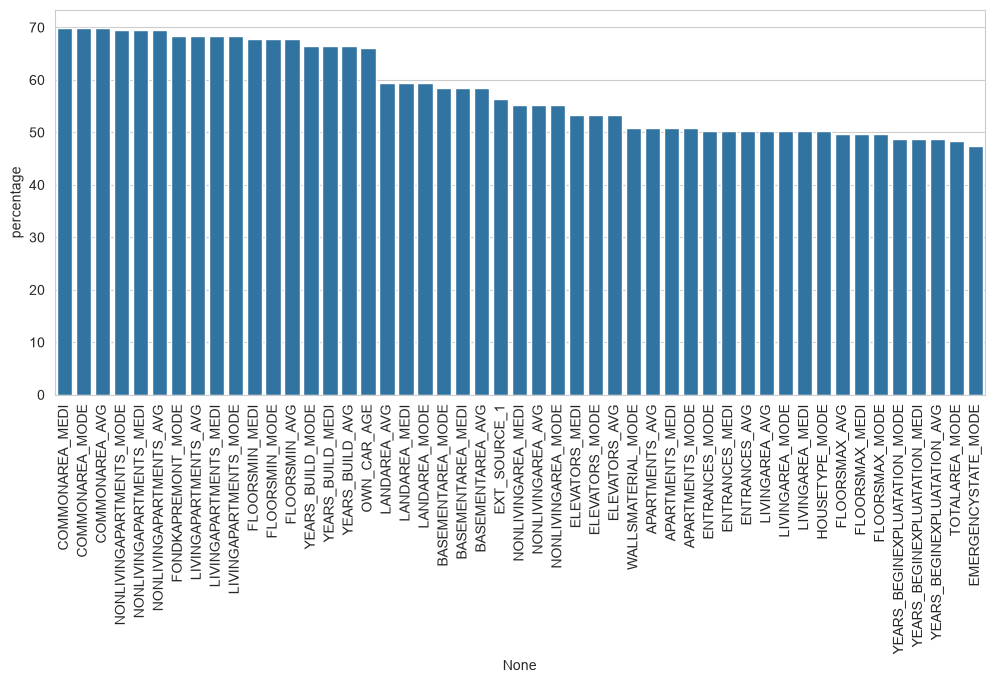

In [46]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=high_missing.index,
    y=high_missing["percentage"]
)

plt.xticks(rotation=90)
plt.show()

Several features contain more than 40% missing values.

These columns will not be removed immediately.

Business relevance will be evaluated before making any decision.

In [47]:
unique_df = pd.DataFrame({
    "Unique Values":df.nunique()
})

unique_df.sort_values(
    by="Unique Values",
    ascending=False
).head(20)

,Unique Values
SK_ID_CURR,307511
EXT_SOURCE_2,119831
EXT_SOURCE_1,114584
DAYS_BIRTH,17460
DAYS_REGISTRATION,15688
AMT_ANNUITY,13672
DAYS_EMPLOYED,12574
DAYS_ID_PUBLISH,6168
AMT_CREDIT,5603
LIVINGAREA_MODE,5301


# EDA Report

In [48]:
num_summary.to_csv("../reports/numerical_summary.csv")
cat_summary.to_csv("../reports/categorical_summary.csv")
missing_df.to_csv("../reports/missing_value_report.csv")

## Idhu GitHub README-la add pannina project romba professional-a irukkum.

Dataset contains 307,511 customers and 122 features.

• Numerical Features: 106
• Categorical Features: 16

Major Findings:

1. Dataset is highly imbalanced (92:8).

2. Several columns contain >40% missing values.

3. Some features contain only a single unique value.

4. Memory usage is approximately XX MB.

5. High-cardinality categorical variables require special encoding.

Recommendations:

• Perform missing value imputation.

• Aggregate external tables before merging.

• Engineer financial ratio features.

• Handle class imbalance using SMOTE or class weights.

• Use Precision, Recall, F1-score, and ROC-AUC for evaluation.


## Business Numerical Feature Analysis

Objective

This phase explores the most important numerical variables from a business perspective.

The analysis includes:

- Histogram Analysis
- KDE Distribution
- Box Plot Analysis
- Skewness Analysis
- Outlier Detection

## Business Value

Understanding customer financial behavior helps:

- Improve feature engineering
- Detect risky customers
- Improve model performance
- Reduce business risk

In [49]:
num_cols

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=106)

In [50]:
business_num_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"
]

print("Number of Selected Features:", len(business_num_cols))
business_num_cols

Number of Selected Features: 11


['AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'CNT_CHILDREN',
 'CNT_FAM_MEMBERS',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3']

In [51]:
available_cols = [col for col in business_num_cols if col in df.columns]
missing_cols = [col for col in business_num_cols if col not in df.columns]

print("Available Columns:",available_cols)

print("Missing Columns",missing_cols)

Available Columns: ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
Missing Columns []


# Histogram 

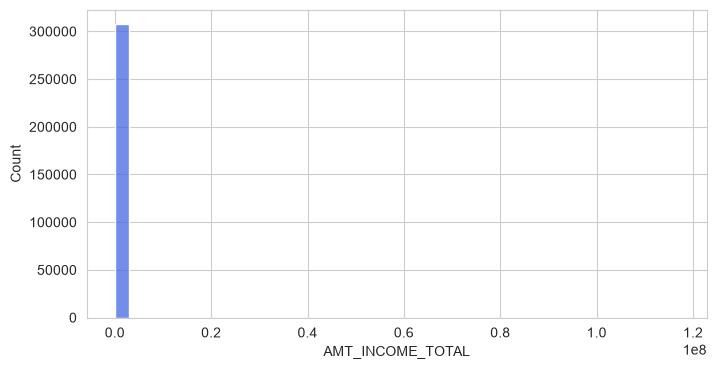

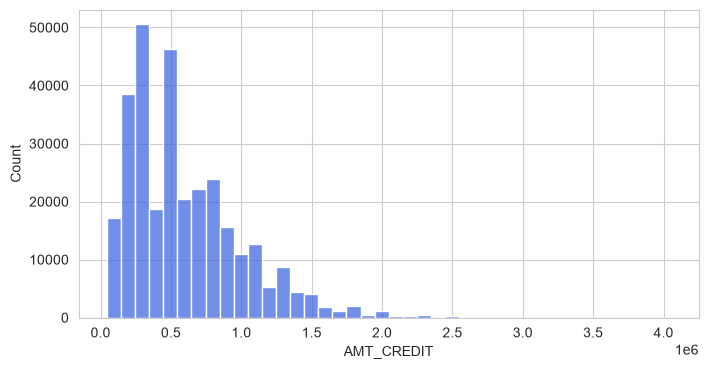

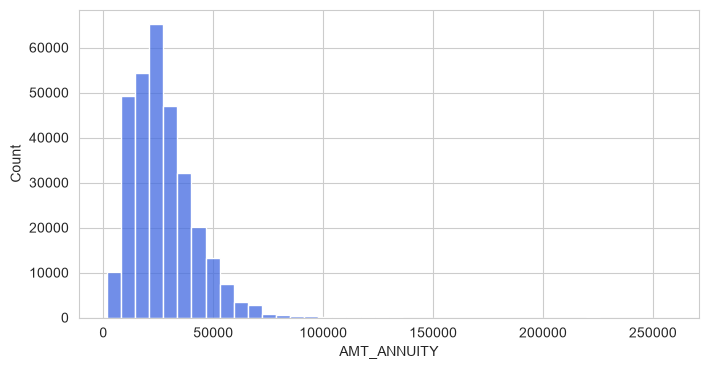

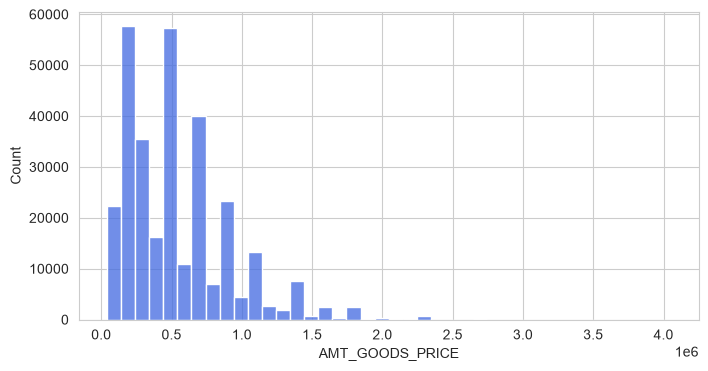

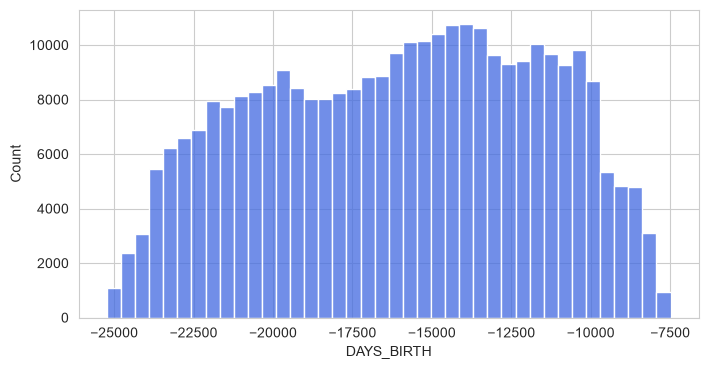

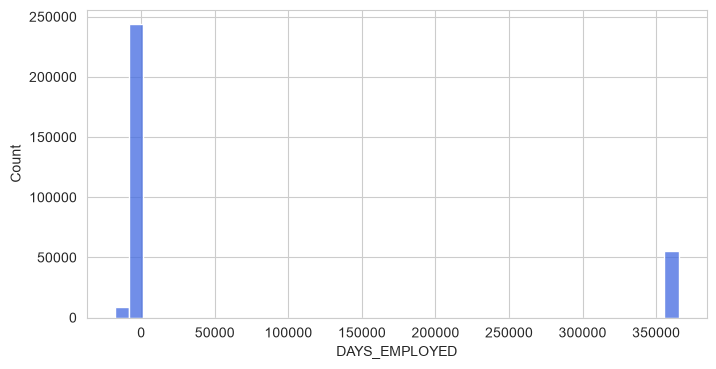

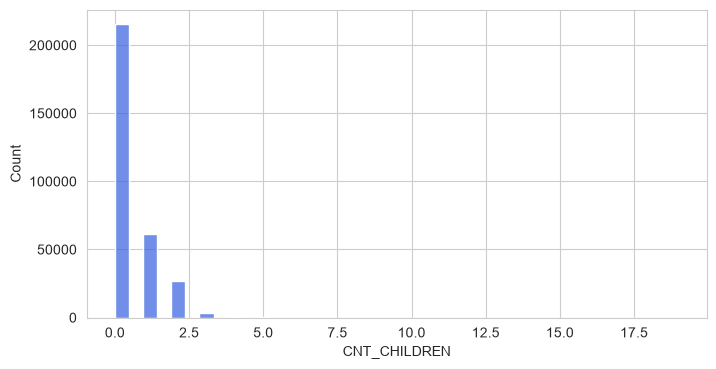

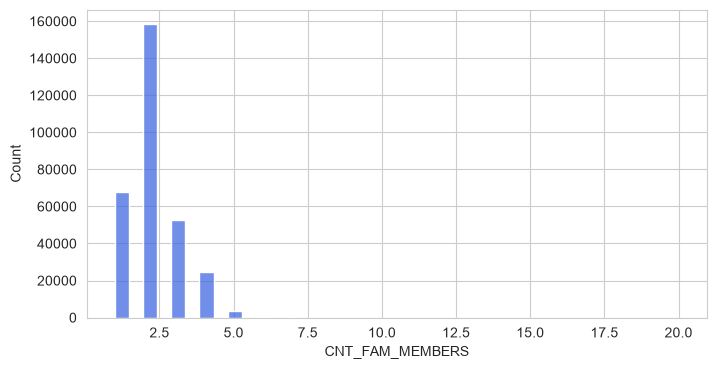

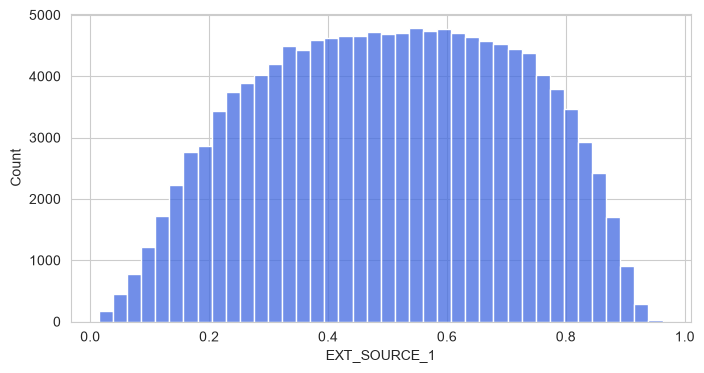

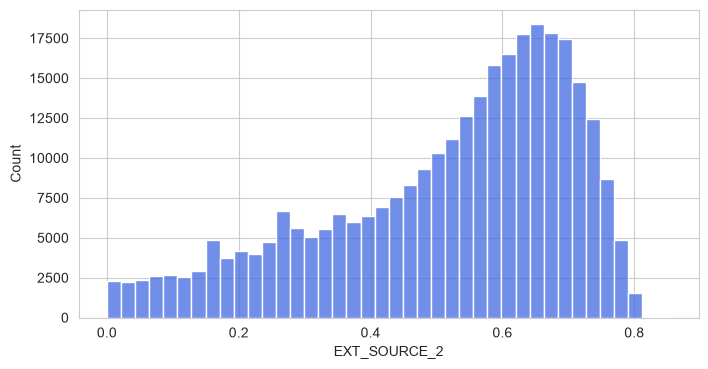

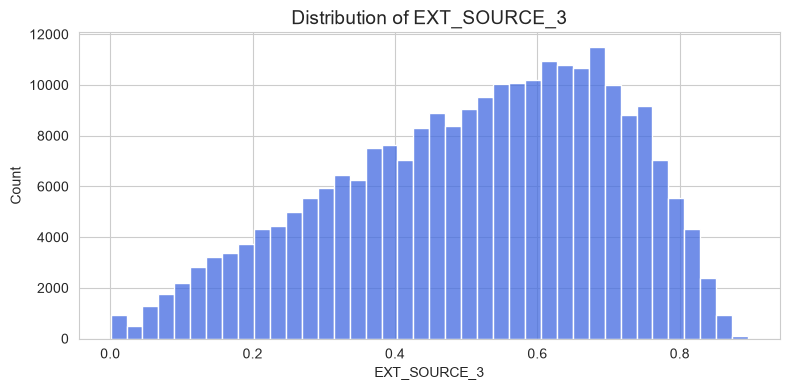

In [52]:
for col in available_cols:
    
    plt.figure(figsize=(8,4))

    sns.histplot(
        data=df,
        x=col,
        color='royalblue',
        bins=40
    )

plt.title(f"Distribution of {col}",fontsize=14)

plt.xlabel(col)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

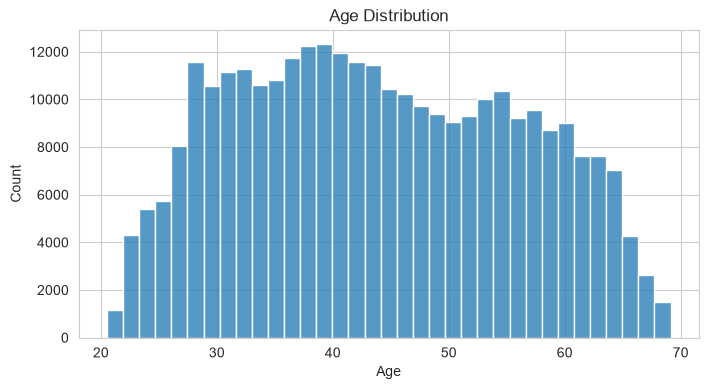

In [53]:
age = abs(df["DAYS_BIRTH"]) / 365

plt.figure(figsize=(8,4))

sns.histplot(age, bins=35)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.show()

# KDE Analysis

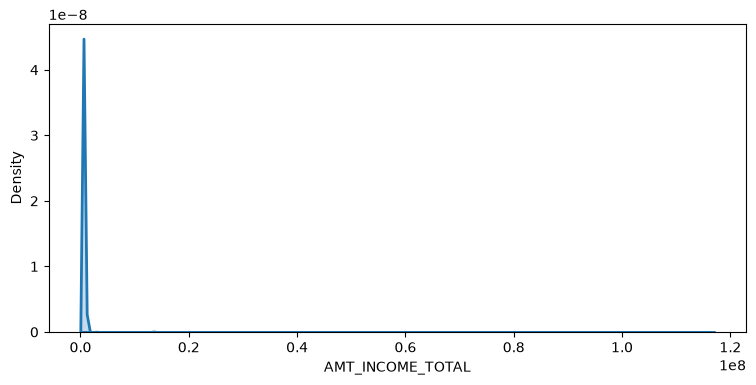

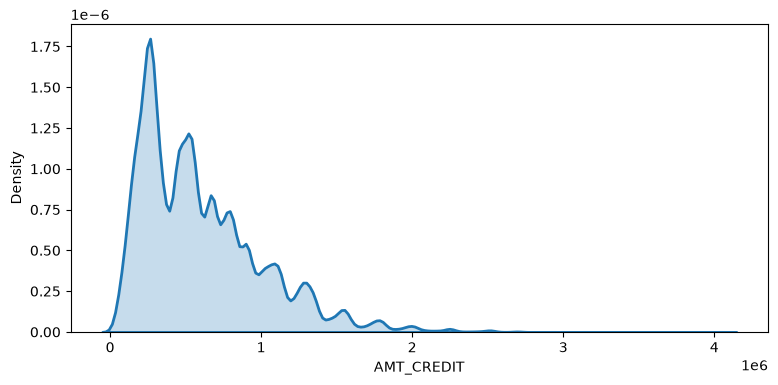

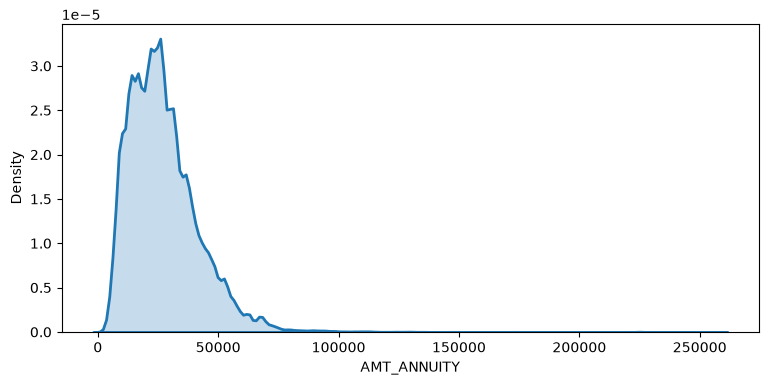

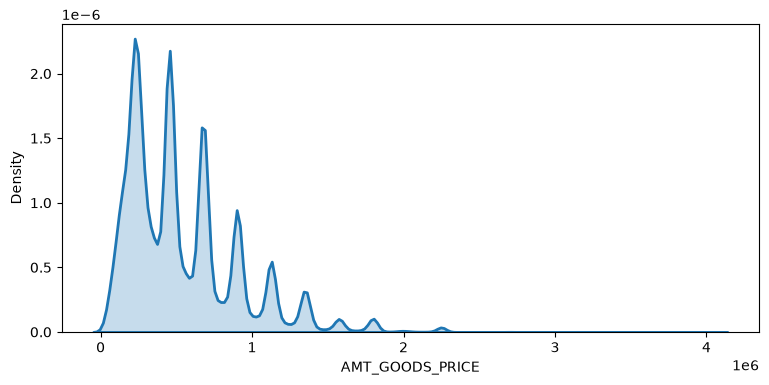

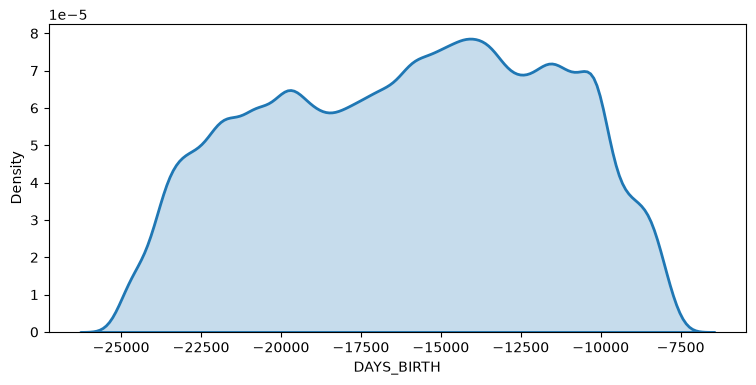

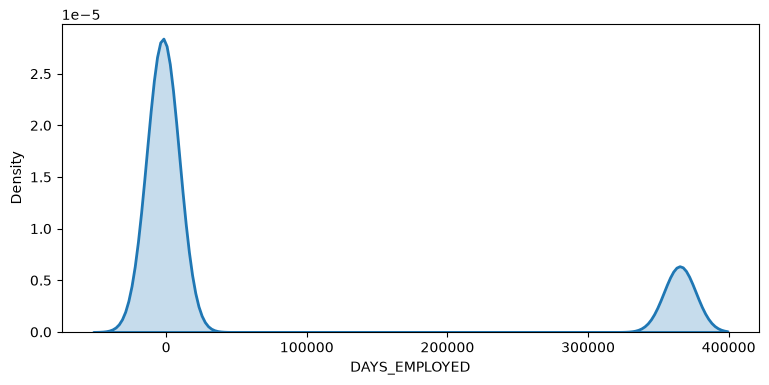

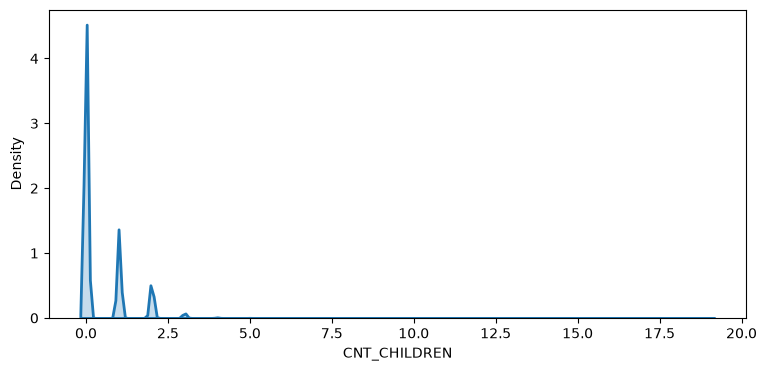

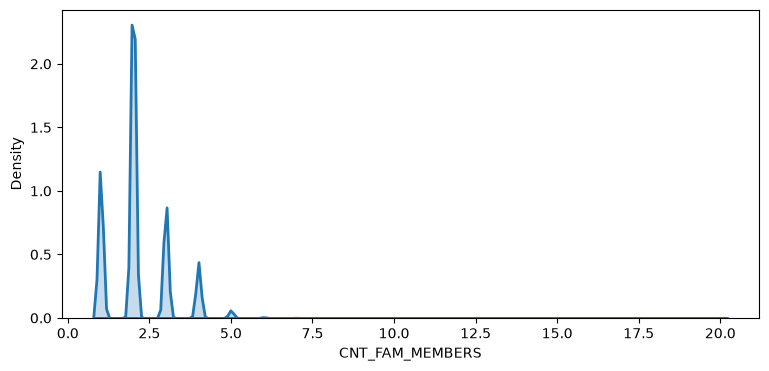

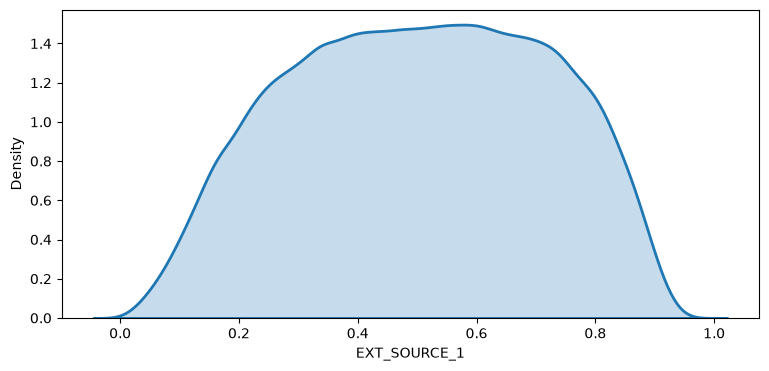

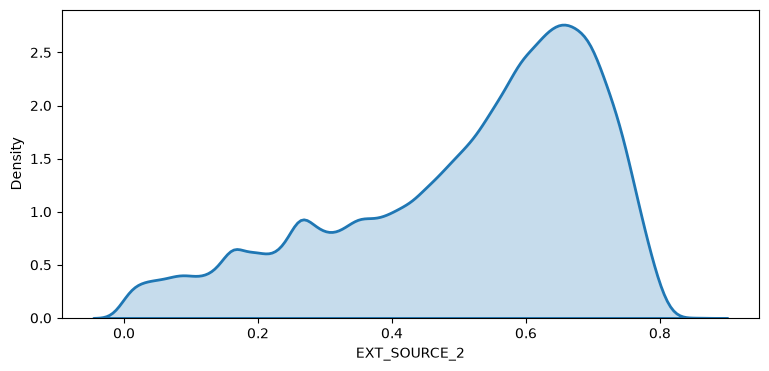

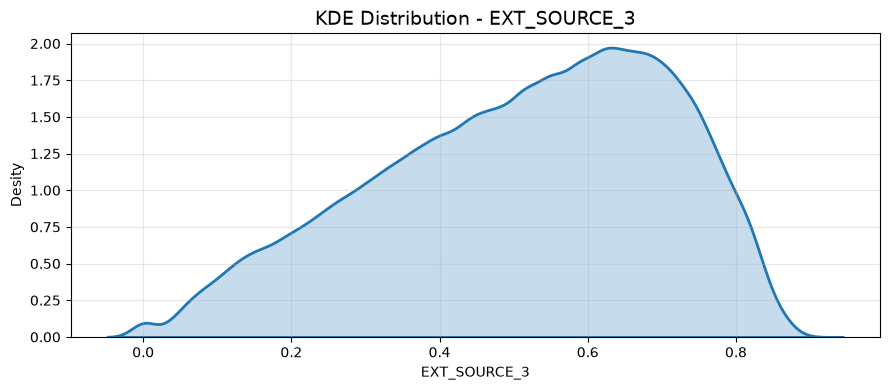

In [54]:
plt.style.use("default")

for col in available_cols:
    plt.figure(figsize=(9,4))

    sns.kdeplot(
        data=df,
        x=col,
        fill=True,
        linewidth=2
    )

plt.title(f"KDE Distribution - {col}",fontsize=14)

plt.xlabel(col)
plt.ylabel("Desity")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

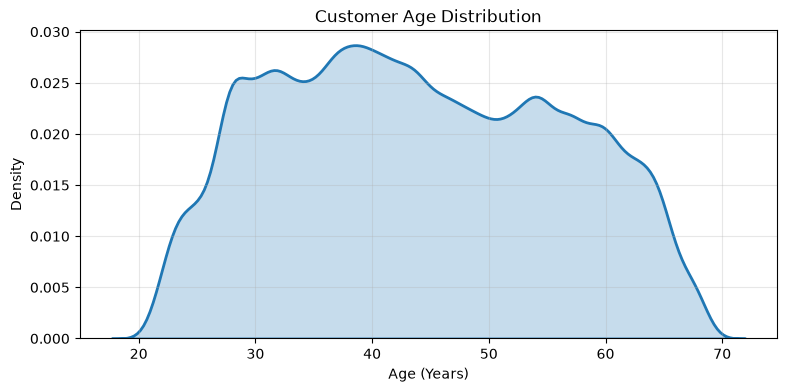

In [55]:
age = abs(df["DAYS_BIRTH"]) / 365

plt.figure(figsize=(9,4))

sns.kdeplot(
    x=age,
    fill=True,
    linewidth=2
)

plt.title("Customer Age Distribution")

plt.xlabel("Age (Years)")

plt.ylabel("Density")

plt.grid(alpha=0.3)

plt.show()

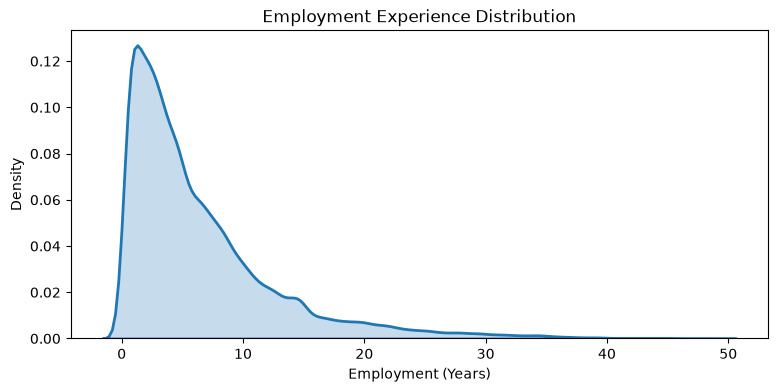

In [56]:
temp = df.copy()

temp["DAYS_EMPLOYED"] = temp["DAYS_EMPLOYED"].replace(365243, np.nan)

employment_years = abs(temp["DAYS_EMPLOYED"]) / 365

plt.figure(figsize=(9,4))

sns.kdeplot(
    x=employment_years,
    fill=True,
    linewidth=2
)

plt.title("Employment Experience Distribution")

plt.xlabel("Employment (Years)")

plt.ylabel("Density")

plt.show()

# Boxplot

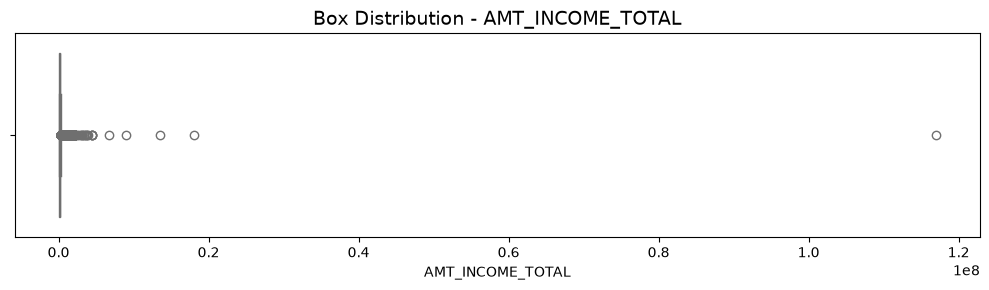

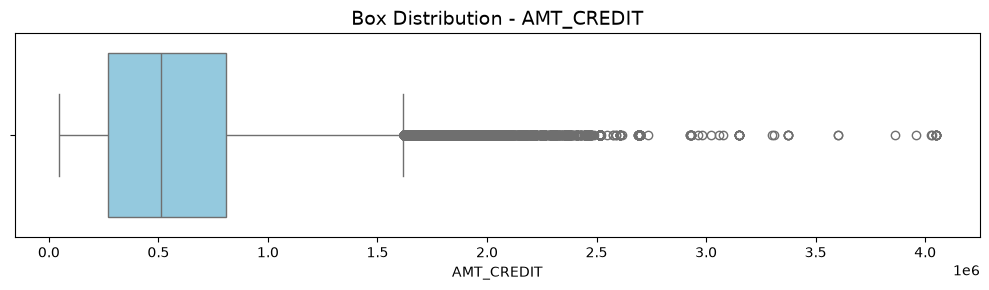

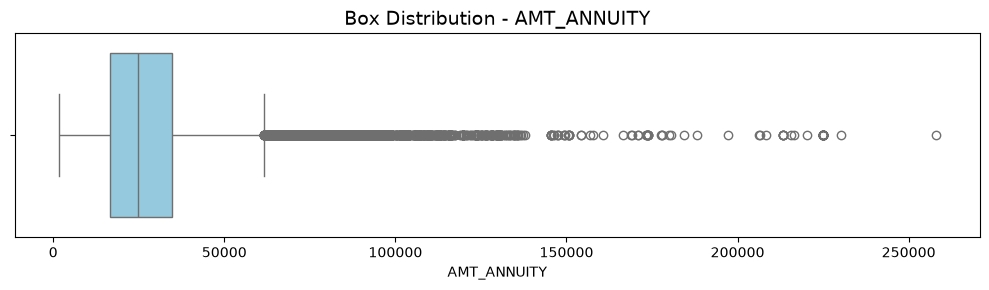

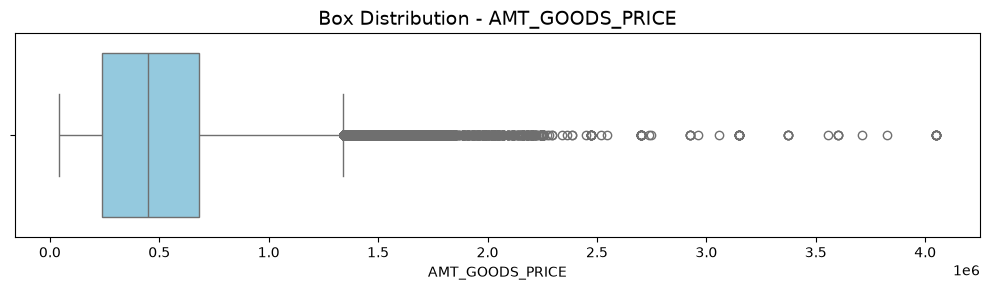

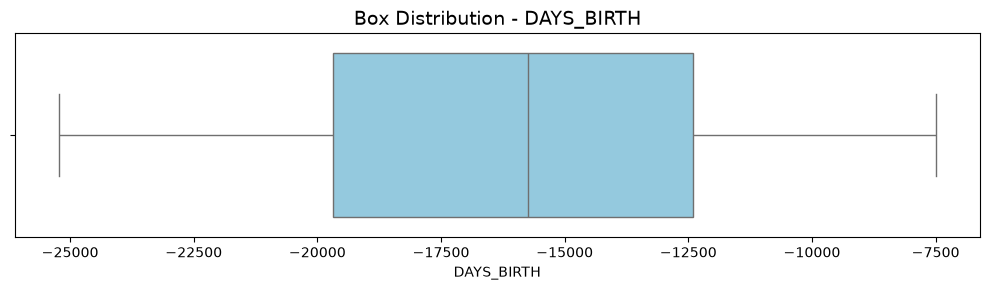

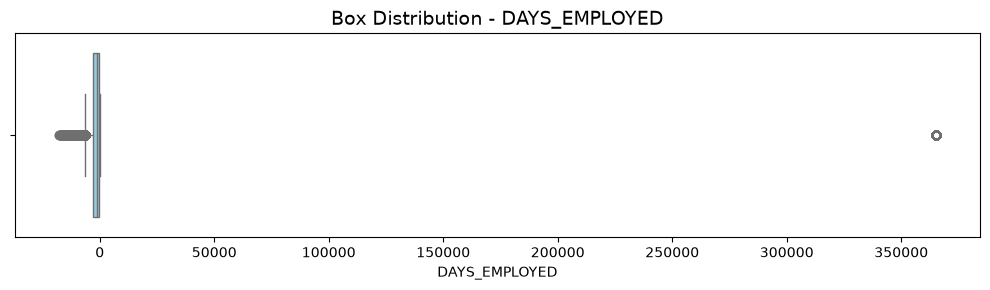

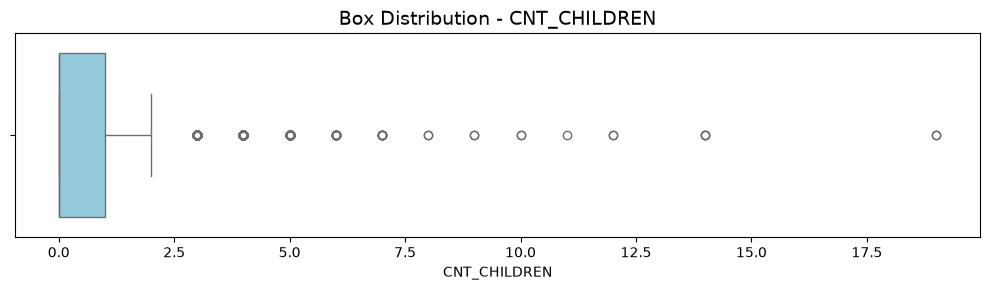

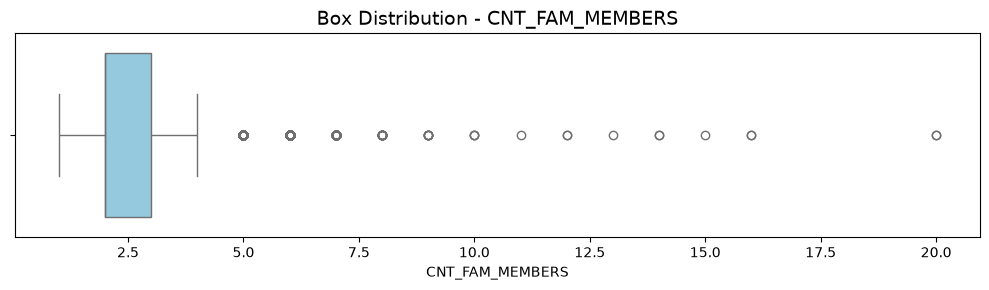

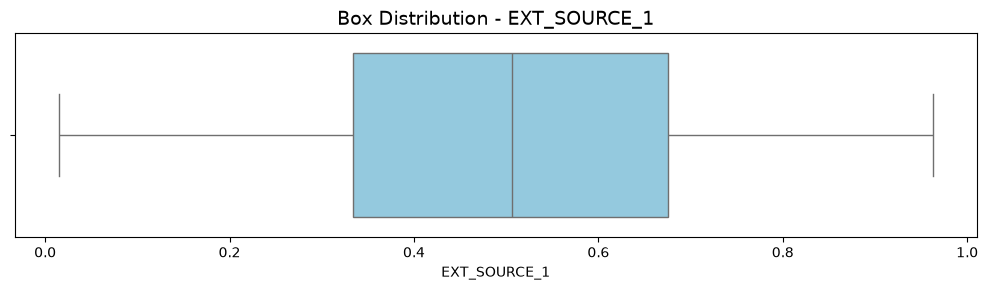

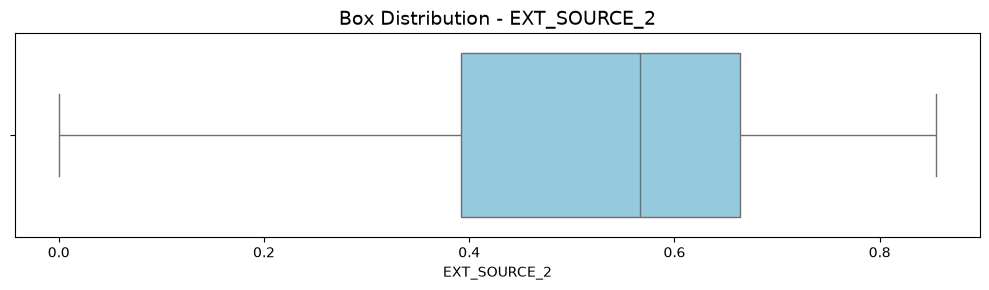

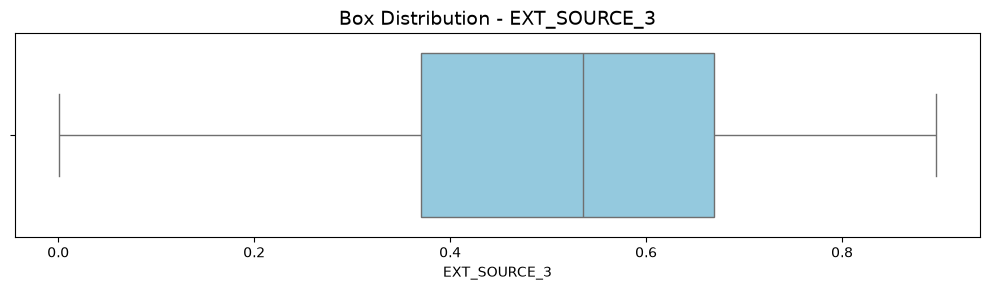

In [57]:
for col in available_cols:

    plt.figure(figsize=(10,3))

    sns.boxplot(
        data=df,
        x=col,
        color="skyblue"
    )

    plt.title(f"Box Distribution - {col}", fontsize=14)
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

# IQR ---> Outlayers

In [58]:
outlier_summary = []

for col in available_cols:

    data = df[col].dropna()

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = data [ 
        (data<lower_bound) |
        (data>upper_bound)
    ]

    outlier_summary.append({
        "Feature":col,
        "Outlier Count":len(outliers),
        "Outliers Percentage": round(len(outliers)/len(data)*100,2)
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df.sort_values(
    by="Outliers Percentage",
    ascending=False
)

,Feature,Outlier Count,Outliers Percentage
5,DAYS_EMPLOYED,72217,23.48
3,AMT_GOODS_PRICE,14728,4.79
0,AMT_INCOME_TOTAL,14035,4.56
2,AMT_ANNUITY,7504,2.44
1,AMT_CREDIT,6562,2.13
6,CNT_CHILDREN,4272,1.39
7,CNT_FAM_MEMBERS,4007,1.30
4,DAYS_BIRTH,0,0.00
8,EXT_SOURCE_1,0,0.00
9,EXT_SOURCE_2,0,0.00


In [59]:
def classify_outliers(percent):
    if percent < 1:
        return "Low"
    elif percent < 5:
        return "Moderate"
    else:
        return "High"

outlier_df['Severity'] = outlier_df["Outliers Percentage"].apply(classify_outliers)

outlier_df.sort_values(
    by="Outliers Percentage",
    ascending=False
)

,Feature,Outlier Count,Outliers Percentage,Severity
5,DAYS_EMPLOYED,72217,23.48,High
3,AMT_GOODS_PRICE,14728,4.79,Moderate
0,AMT_INCOME_TOTAL,14035,4.56,Moderate
2,AMT_ANNUITY,7504,2.44,Moderate
1,AMT_CREDIT,6562,2.13,Moderate
6,CNT_CHILDREN,4272,1.39,Moderate
7,CNT_FAM_MEMBERS,4007,1.30,Moderate
4,DAYS_BIRTH,0,0.00,Low
8,EXT_SOURCE_1,0,0.00,Low
9,EXT_SOURCE_2,0,0.00,Low


## Calculate Skewness

In [60]:
skewness_df = pd.DataFrame({
    "Feature": available_cols,
    "Skewness": [df[col].skew() for col in available_cols]
})

skewness_df = skewness_df.sort_values(
    by="Skewness",
    key=abs,
    ascending=False                                 
                                      )

skewness_df.reset_index(drop=True,inplace=True)

skewness_df

,Feature,Skewness
0,AMT_INCOME_TOTAL,391.559654
1,CNT_CHILDREN,1.974604
2,DAYS_EMPLOYED,1.664346
3,AMT_ANNUITY,1.579777
4,AMT_GOODS_PRICE,1.349000
5,AMT_CREDIT,1.234778
6,CNT_FAM_MEMBERS,0.987543
7,EXT_SOURCE_2,-0.793576
8,EXT_SOURCE_3,-0.409390
9,DAYS_BIRTH,-0.115673


In [61]:
def skew_category(value):

    if abs(value) < 0.5:
        return "Approximately Symmetric"
    elif abs(value) < 1:
        return "Moderately Skewed"
    else:
        return "highly Skewed"
    
skewness_df["Distribution"] = skewness_df["Skewness"].apply(skew_category)

skewness_df

,Feature,Skewness,Distribution
0,AMT_INCOME_TOTAL,391.559654,highly Skewed
1,CNT_CHILDREN,1.974604,highly Skewed
2,DAYS_EMPLOYED,1.664346,highly Skewed
3,AMT_ANNUITY,1.579777,highly Skewed
4,AMT_GOODS_PRICE,1.349000,highly Skewed
5,AMT_CREDIT,1.234778,highly Skewed
6,CNT_FAM_MEMBERS,0.987543,Moderately Skewed
7,EXT_SOURCE_2,-0.793576,Moderately Skewed
8,EXT_SOURCE_3,-0.409390,Approximately Symmetric
9,DAYS_BIRTH,-0.115673,Approximately Symmetric


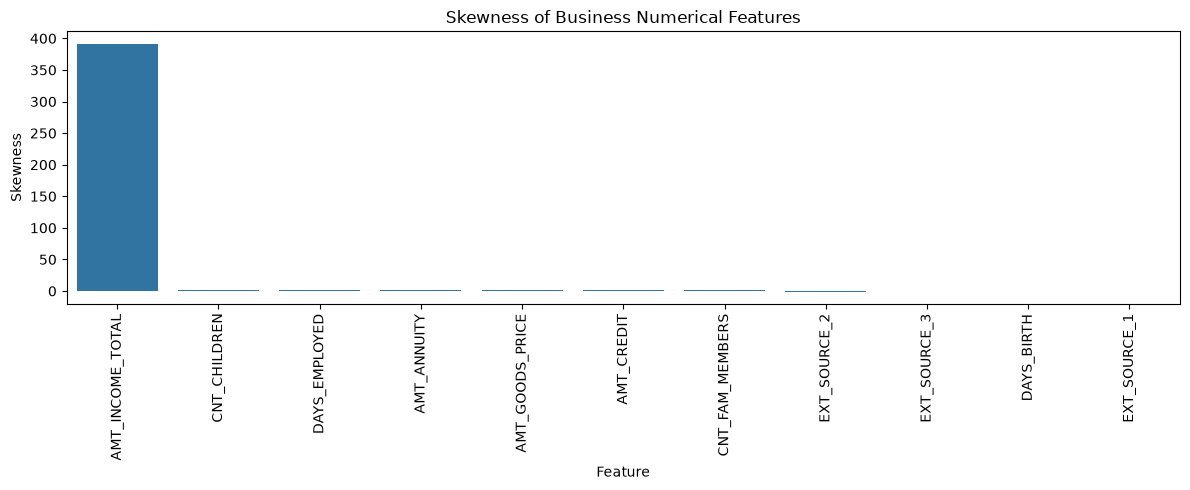

In [62]:
plt.figure(figsize=(12,5))

sns.barplot(
    data = skewness_df,
    x = "Feature",
    y = "Skewness"
)

plt.xticks(rotation=90)

plt.title("Skewness of Business Numerical Features")

plt.tight_layout()

plt.show()

In [63]:
transformation_df = skewness_df.copy()

transformation_df["Recommended Transformation"] = transformation_df["Skewness"].apply(
    lambda x:

    "Log Transform"

    if abs(x) > 1

    else "No Immediate Transformation"
)

transformation_df

,Feature,Skewness,Distribution,Recommended Transformation
0,AMT_INCOME_TOTAL,391.559654,highly Skewed,Log Transform
1,CNT_CHILDREN,1.974604,highly Skewed,Log Transform
2,DAYS_EMPLOYED,1.664346,highly Skewed,Log Transform
3,AMT_ANNUITY,1.579777,highly Skewed,Log Transform
4,AMT_GOODS_PRICE,1.349000,highly Skewed,Log Transform
5,AMT_CREDIT,1.234778,highly Skewed,Log Transform
6,CNT_FAM_MEMBERS,0.987543,Moderately Skewed,No Immediate Transformation
7,EXT_SOURCE_2,-0.793576,Moderately Skewed,No Immediate Transformation
8,EXT_SOURCE_3,-0.409390,Approximately Symmetric,No Immediate Transformation
9,DAYS_BIRTH,-0.115673,Approximately Symmetric,No Immediate Transformation


## Categorical Feature Analysis

In [64]:
business_cat_cols = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE"
]

print("Selected Business Categorical Features:")
print(business_cat_cols)

Selected Business Categorical Features:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']


In [65]:
available_cat_cols = [col for col in business_cat_cols if col in df.columns]

missing_cat_cols = [col for col in business_cat_cols if col not in df.columns]

print("Available Columns:")
print(available_cat_cols)

print("Missing Columns:")
print(missing_cat_cols)

Available Columns:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']
Missing Columns:
[]


In [66]:
for col in available_cat_cols:

    print("=" * 60)
    print(f"Feature : {col}")
    print("=" * 60)

    display(df[col].value_counts(dropna=False))

Feature : NAME_CONTRACT_TYPE


NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64

Feature : CODE_GENDER


CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

Feature : FLAG_OWN_CAR


...

NAME_HOUSING_TYPE
House / apartment      272868
With parents            14840
Municipal apartment     11183
Rented apartment         4881
Office apartment         2617
Co-op apartment          1122
Name: count, dtype: int64

Feature : OCCUPATION_TYPE


OCCUPATION_TYPE
NaN                      96391
Laborers                 55186
Sales staff              32102
Core staff               27570
Managers                 21371
Drivers                  18603
High skill tech staff    11380
Accountants               9813
Medicine staff            8537
Security staff            6721
Cooking staff             5946
Cleaning staff            4653
Private service staff     2652
Low-skill Laborers        2093
Waiters/barmen staff      1348
Secretaries               1305
Realty agents              751
HR staff                   563
IT staff                   526
Name: count, dtype: int64

Feature : ORGANIZATION_TYPE


ORGANIZATION_TYPE
Business Entity Type 3    67992
XNA                       55374
Self-employed             38412
Other                     16683
Medicine                  11193
Business Entity Type 2    10553
Government                10404
School                     8893
Trade: type 7              7831
Kindergarten               6880
Construction               6721
Business Entity Type 1     5984
Transport: type 4          5398
Trade: type 3              3492
Industry: type 9           3368
Industry: type 3           3278
Security                   3247
Housing                    2958
Industry: type 11          2704
Military                   2634
Bank                       2507
Agriculture                2454
Police                     2341
Transport: type 2          2204
Postal                     2157
Security Ministries        1974
Trade: type 2              1900
Restaurant                 1811
Services                   1575
University                 1327
Industry: type 7      

## Count Plot for categorical Features

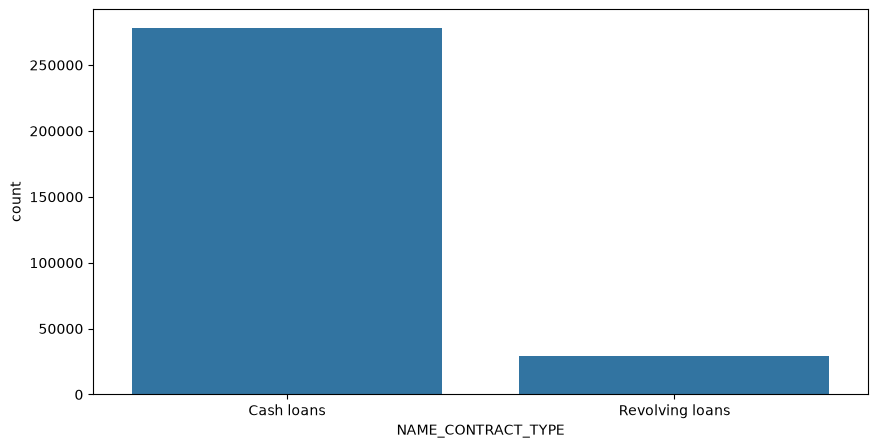

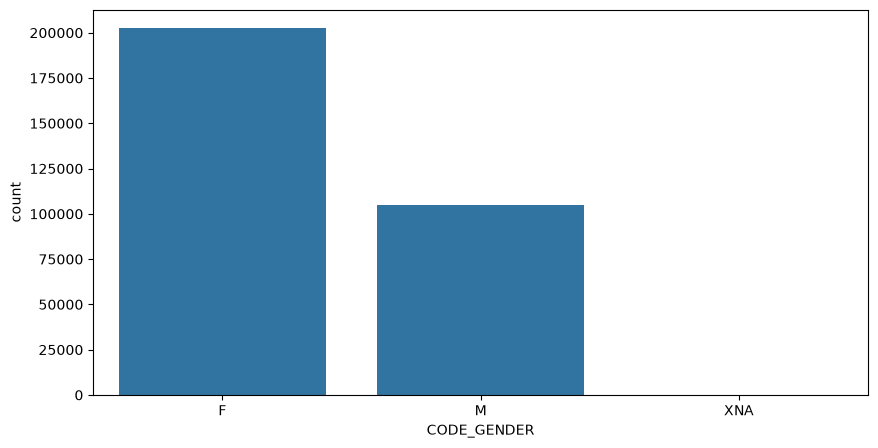

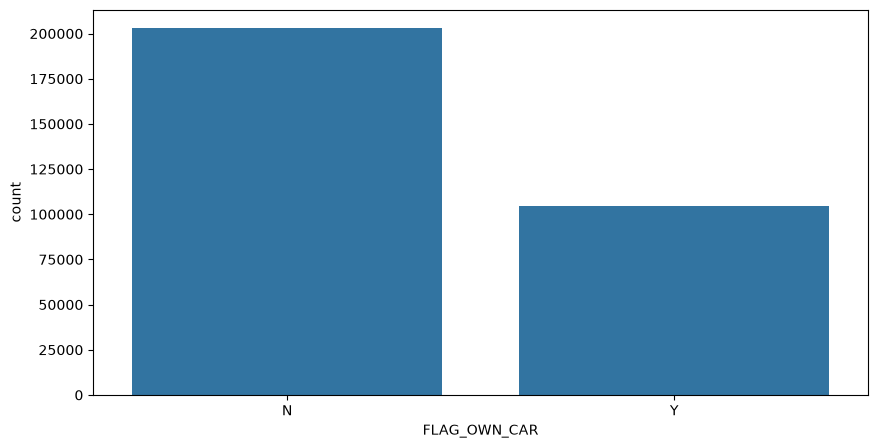

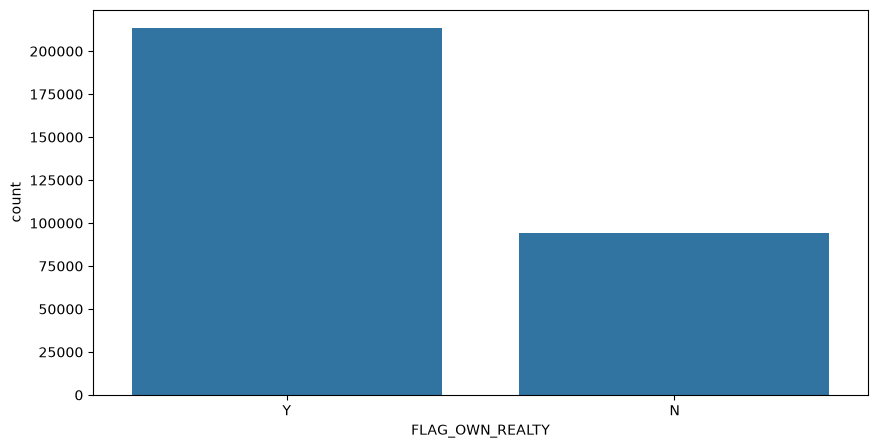

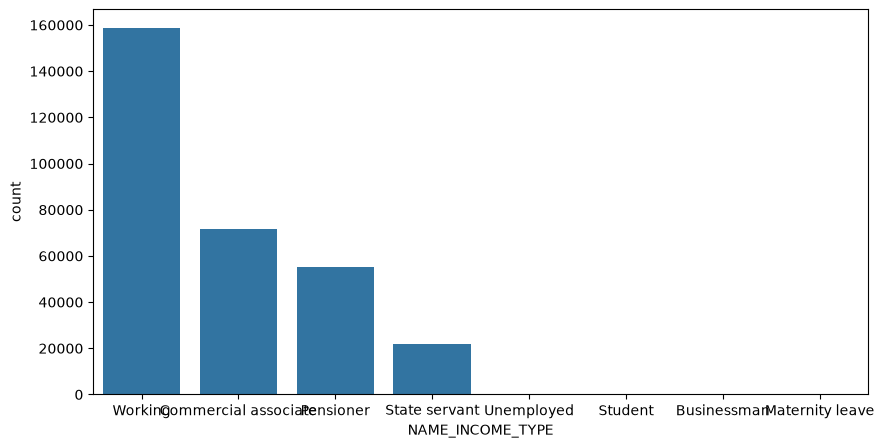

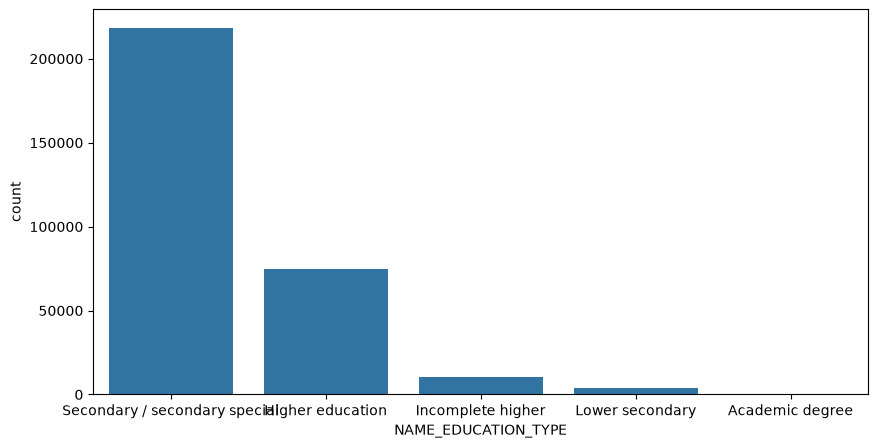

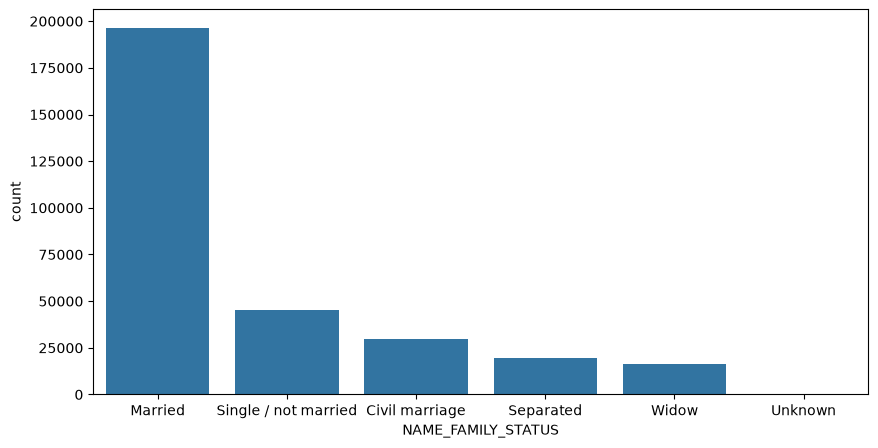

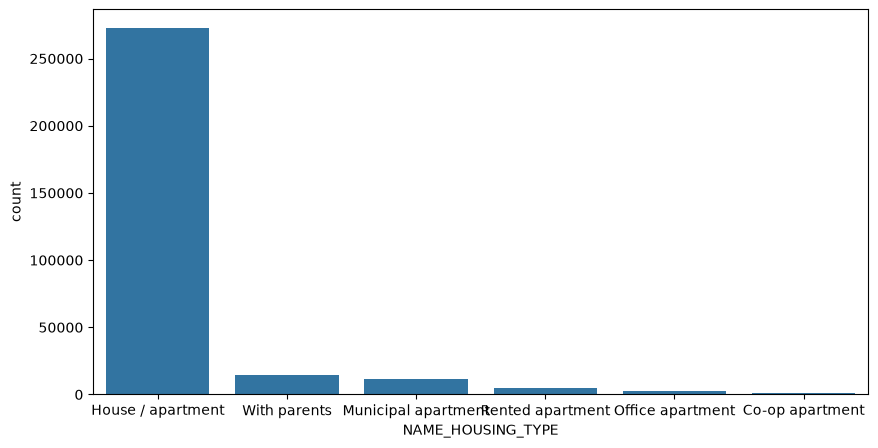

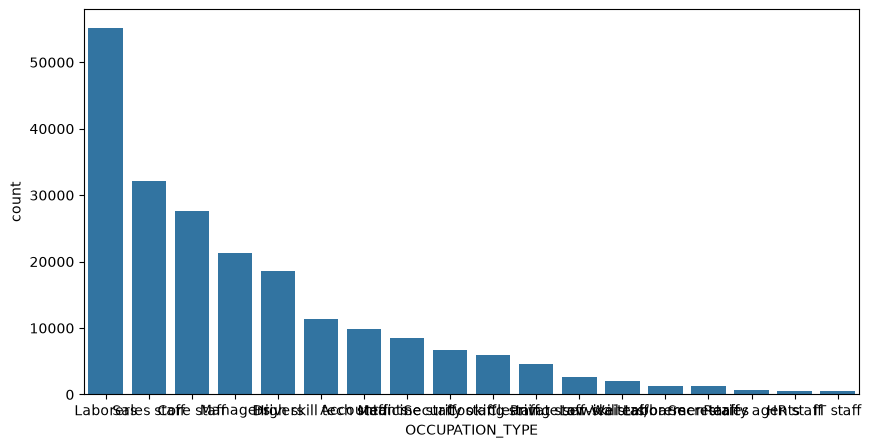

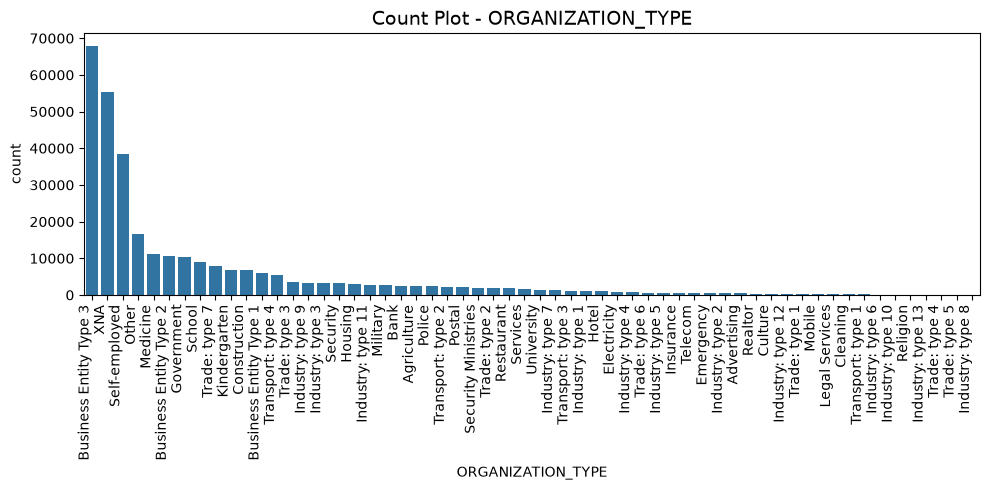

In [67]:
for col in available_cat_cols:

    plt.figure(figsize=(10,5))

    sns.countplot(
        data = df,
        x = col,
        order = df[col].value_counts().index
    )

plt.title(f"Count Plot - {col}",fontsize=14)

plt.xticks(rotation=90,ha="right")

plt.tight_layout()

plt.show()

In [68]:
for col in available_cat_cols:

    print("="*60)
    print(f"Percentage Distribution:{col}")
    print("="*60)

    percentage = (
        df[col].value_counts(normalize=True,dropna=False)
        .mul(100)
        .round(2)
    )
    
    display(percentage.to_frame(name="Percentage"))

Percentage Distribution:NAME_CONTRACT_TYPE


,Percentage
NAME_CONTRACT_TYPE,
Cash loans,90.48
Revolving loans,9.52


Percentage Distribution:CODE_GENDER


,Percentage
CODE_GENDER,
F,65.83
M,34.16
XNA,0.00


Percentage Distribution:FLAG_OWN_CAR


...

,Percentage
NAME_HOUSING_TYPE,
House / apartment,88.73
With parents,4.83
Municipal apartment,3.64
Rented apartment,1.59
Office apartment,0.85
Co-op apartment,0.36


Percentage Distribution:OCCUPATION_TYPE


,Percentage
OCCUPATION_TYPE,
NaN,31.35
Laborers,17.95
Sales staff,10.44
Core staff,8.97
Managers,6.95
Drivers,6.05
High skill tech staff,3.70
Accountants,3.19
Medicine staff,2.78


Percentage Distribution:ORGANIZATION_TYPE


,Percentage
ORGANIZATION_TYPE,
Business Entity Type 3,22.11
XNA,18.01
Self-employed,12.49
Other,5.43
Medicine,3.64
Business Entity Type 2,3.43
Government,3.38
School,2.89
Trade: type 7,2.55


In [69]:
summary = []

for col in available_cat_cols:

    summary.append({

        "Feature":col,

        "Unique Categories": df[col].nunique(dropna=False),

        "Most Frequent Category": df[col].mode(dropna=True)[0],

        "Frequency": df[col].value_counts().iloc[0],
        
        "Missing Values": df[col].isna().sum()

    })

summary_df = pd.DataFrame(summary)

summary_df

,Feature,Unique Categories,Most Frequent Category,Frequency,Missing Values
0,NAME_CONTRACT_TYPE,2,Cash loans,278232,0
1,CODE_GENDER,3,F,202448,0
2,FLAG_OWN_CAR,2,N,202924,0
3,FLAG_OWN_REALTY,2,Y,213312,0
4,NAME_INCOME_TYPE,8,Working,158774,0
5,NAME_EDUCATION_TYPE,5,Secondary / secondary special,218391,0
6,NAME_FAMILY_STATUS,6,Married,196432,0
7,NAME_HOUSING_TYPE,6,House / apartment,272868,0
8,OCCUPATION_TYPE,19,Laborers,55186,96391
9,ORGANIZATION_TYPE,58,Business Entity Type 3,67992,0


In [70]:
RARE_THRESHOLD = 1.0   # Percentage

## Detect Rare Categories

In [71]:
rare_category_report = []

for col in available_cat_cols:

    Percentage = (
        df[col].value_counts(normalize=True,dropna=False)
        
        )
    rare = Percentage[Percentage < RARE_THRESHOLD]

    for category,pct in rare.items():

        rare_category_report.append(
            {
                "Feature":col,
                "Category": category,
                "Percentage":round(pct,3)
            }
        )

rare_df = pd.DataFrame(rare_category_report)

rare_df.sort_values(
    ["Feature","Percentage"]
)

,Feature,Category,Percentage
4,CODE_GENDER,XNA,0.000
3,CODE_GENDER,M,0.342
2,CODE_GENDER,F,0.658
6,FLAG_OWN_CAR,Y,0.340
5,FLAG_OWN_CAR,N,0.660
...,...,...,...
57,ORGANIZATION_TYPE,Medicine,0.036
56,ORGANIZATION_TYPE,Other,0.054
55,ORGANIZATION_TYPE,Self-employed,0.125
54,ORGANIZATION_TYPE,XNA,0.180


In [72]:
rare_summary = (
    
    rare_df.groupby("Feature").size().reset_index(name="Rare Category Count")
)
rare_summary

,Feature,Rare Category Count
0,CODE_GENDER,3
1,FLAG_OWN_CAR,2
2,FLAG_OWN_REALTY,2
3,NAME_CONTRACT_TYPE,2
4,NAME_EDUCATION_TYPE,5
5,NAME_FAMILY_STATUS,6
6,NAME_HOUSING_TYPE,6
7,NAME_INCOME_TYPE,8
8,OCCUPATION_TYPE,19
9,ORGANIZATION_TYPE,58


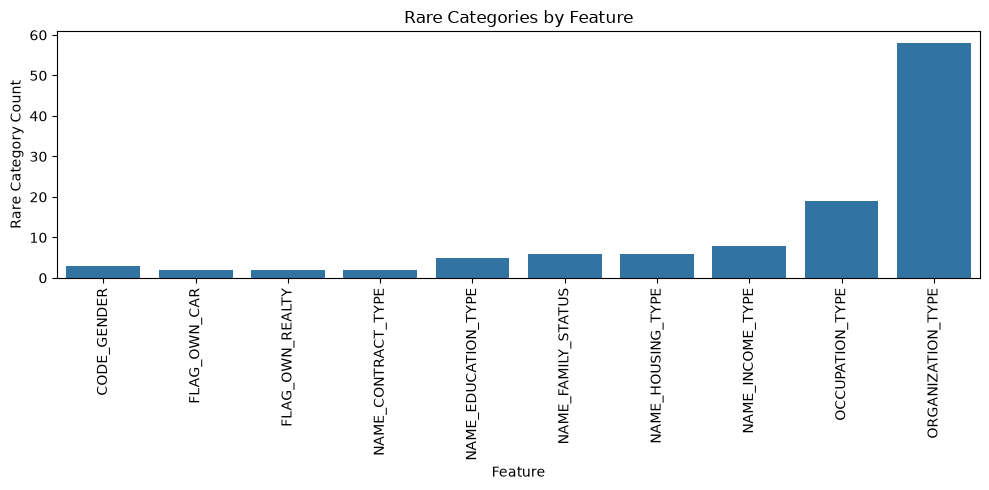

In [73]:
plt.figure(figsize=(10,5))

sns.barplot(
    data = rare_summary,
    x = "Feature",
    y = "Rare Category Count"
)

plt.title("Rare Categories by Feature")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

In [74]:
target_rate_summary = []

for col in available_cat_cols:
    temp= (
        df.groupby(col,dropna=False)["TARGET"].agg(
                                                   Total_Customers="count",
                                                   Default_Rate="mean"
                                                   ).reset_index()
    )

    temp["Feature"] = col

    temp["Default_Rate"] = (temp["Default_Rate"]*100).round(2)

    target_rate_summary.append(temp)

target_rate_df = pd.concat(target_rate_summary,ignore_index=True)

target_rate_df.head()

,NAME_CONTRACT_TYPE,Total_Customers,Default_Rate,Feature,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,ORGANIZATION_TYPE
0,Cash loans,278232,8.35,NAME_CONTRACT_TYPE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Revolving loans,29279,5.48,NAME_CONTRACT_TYPE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,202448,7.00,CODE_GENDER,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,105059,10.14,CODE_GENDER,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,4,0.00,CODE_GENDER,XNA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


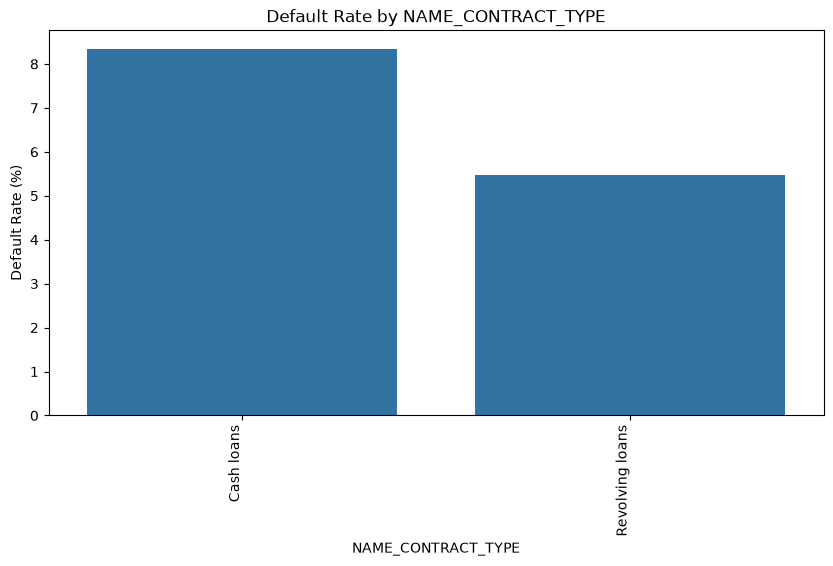

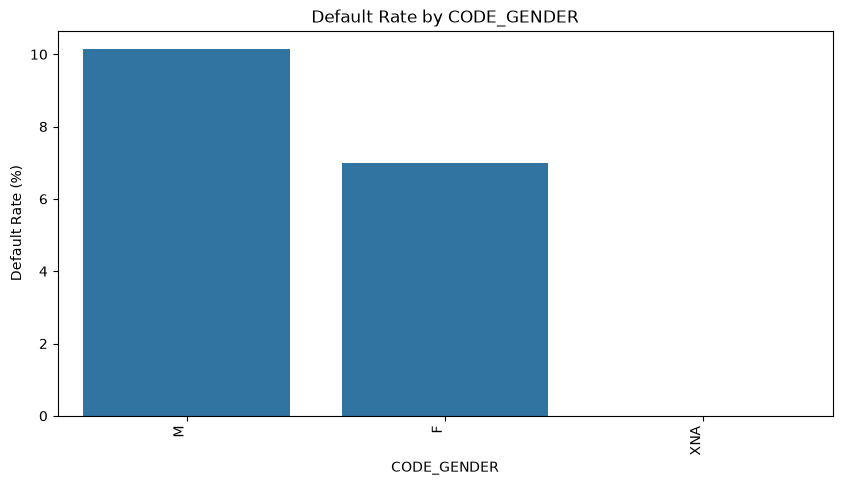

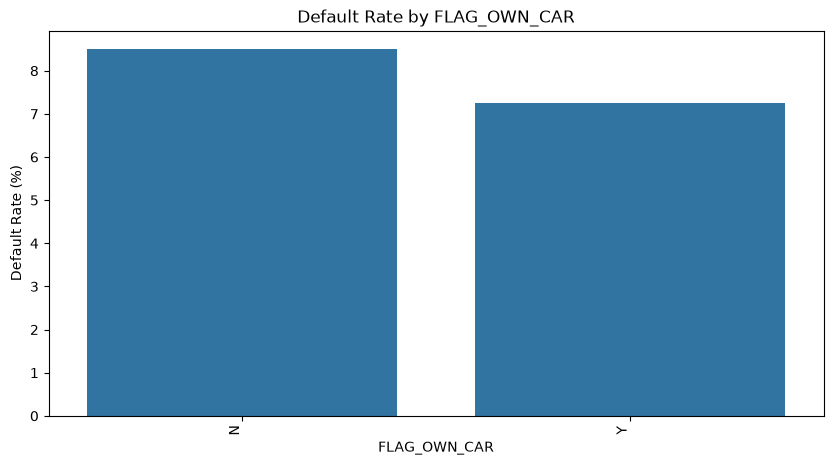

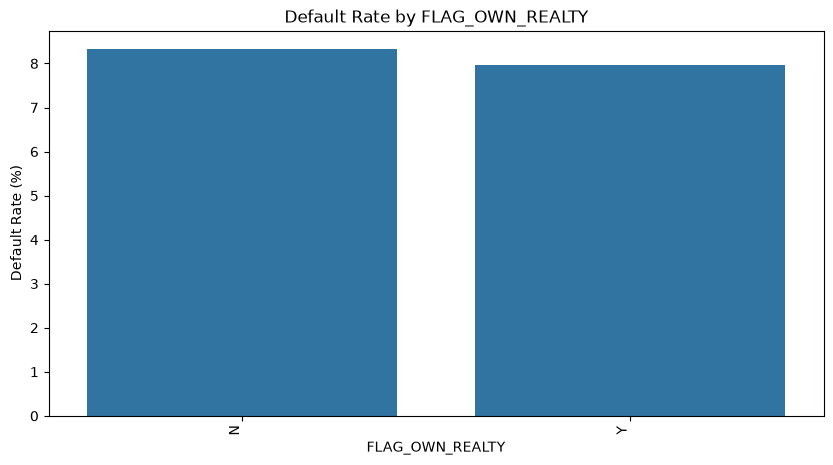

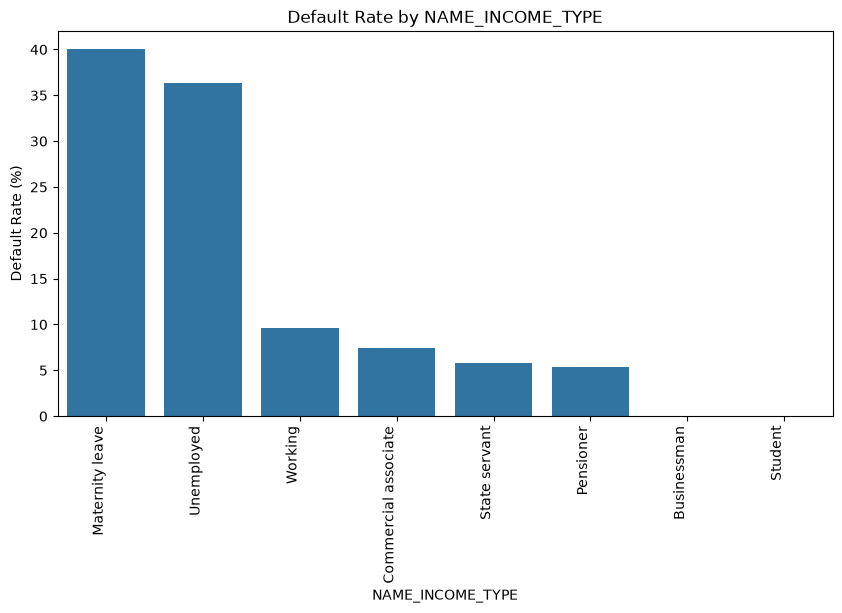

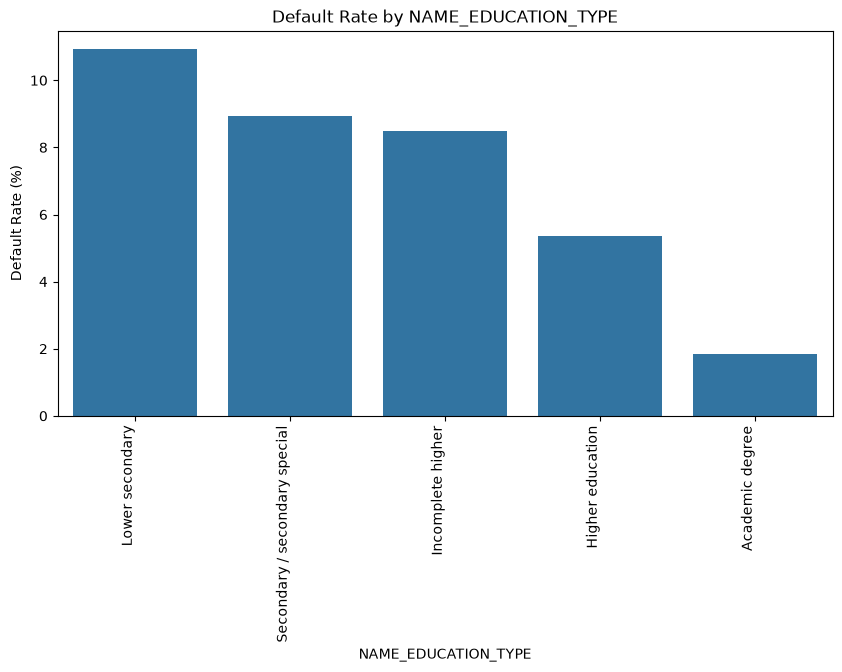

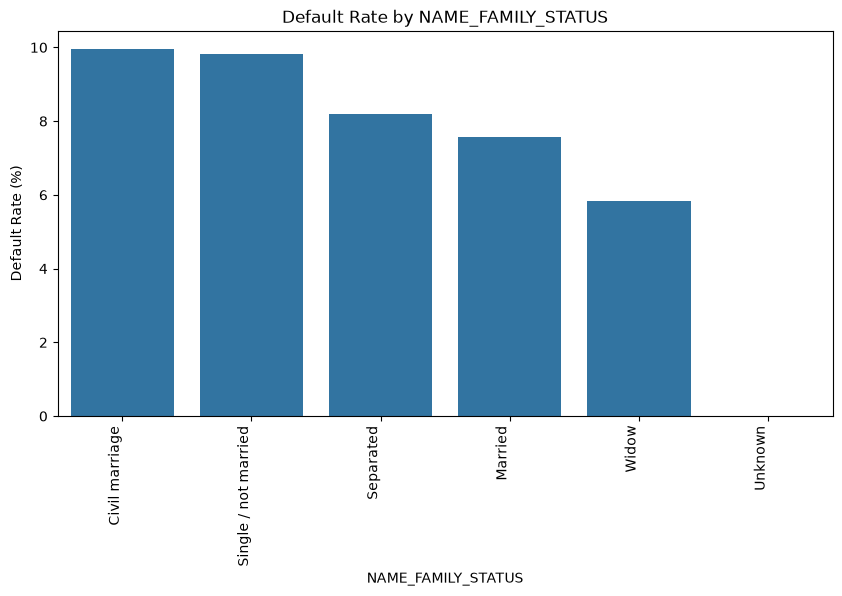

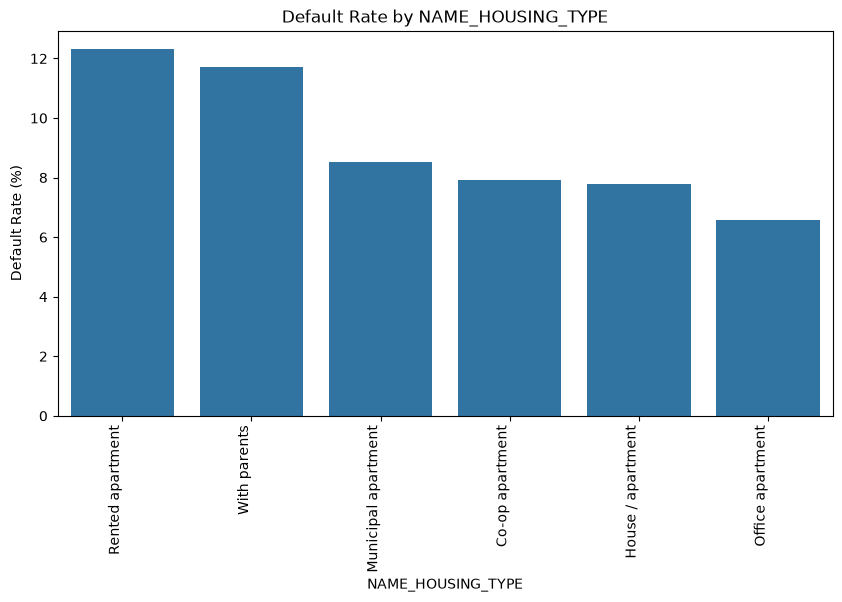

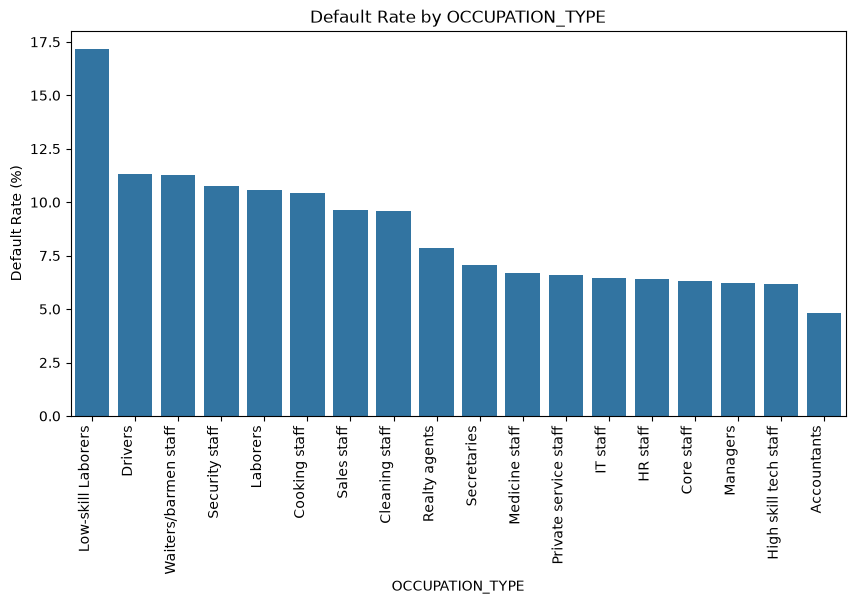

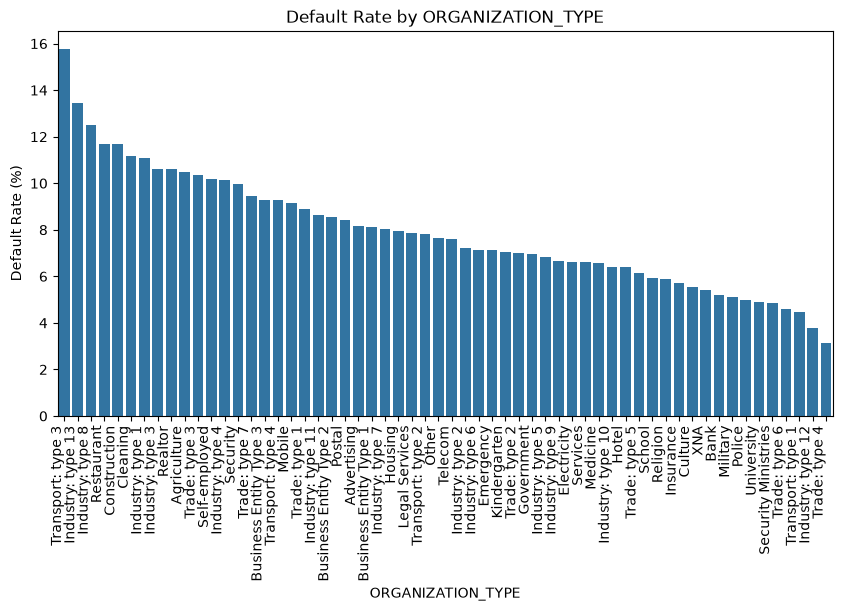

In [75]:
for col in available_cat_cols:

    plt.figure(figsize=(10,5))

    temp = (
            df.groupby(col)["TARGET"].mean().sort_values(ascending=False)*100
    )

    sns.barplot(
        x = temp.index,
        
        y = temp.values
    )

    plt.xticks(rotation=90,ha="right")

    plt.ylabel("Default Rate (%)")

    plt.title(f"Default Rate by {col}")

    plt.show()

In [76]:
high_risk_categories = target_rate_df[
    target_rate_df["Default_Rate"]>20 ].sort_values(by="Default_Rate",ascending=False)

high_risk_categories

,NAME_CONTRACT_TYPE,Total_Customers,Default_Rate,Feature,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,ORGANIZATION_TYPE
11,NaN,5,40.00,NAME_INCOME_TYPE,NaN,NaN,NaN,Maternity leave,NaN,NaN,NaN,NaN,NaN
15,NaN,22,36.36,NAME_INCOME_TYPE,NaN,NaN,NaN,Unemployed,NaN,NaN,NaN,NaN,NaN


In [77]:
def classify_risk(default_rate):

    if default_rate < 8:
        return "Low Risk"
    
    elif default_rate < 15:
        return "Medium Rsik"
    
    else:
        return "High Risk"

target_rate_df["Risk_Level"] = target_rate_df["Default_Rate"].apply(classify_risk)

target_rate_df.head()

,NAME_CONTRACT_TYPE,Total_Customers,Default_Rate,Feature,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,ORGANIZATION_TYPE,Risk_Level
0,Cash loans,278232,8.35,NAME_CONTRACT_TYPE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medium Rsik
1,Revolving loans,29279,5.48,NAME_CONTRACT_TYPE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low Risk
2,NaN,202448,7.00,CODE_GENDER,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low Risk
3,NaN,105059,10.14,CODE_GENDER,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medium Rsik
4,NaN,4,0.00,CODE_GENDER,XNA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low Risk


In [78]:
from scipy.stats import chi2_contingency
import numpy as np

In [79]:
chi_square_results = []

for col in available_cat_cols:

    contingency_table = pd.crosstab(
        df[col],
        df["TARGET"],
        dropna=False
    )

    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    chi_square_results.append({
        "Feature": col,
        "Chi-Square": round(chi2, 2),
        "P-Value": p_value,
        "Degrees_of_Freedom": dof
    })

chi_square_df = pd.DataFrame(chi_square_results)

chi_square_df

,Feature,Chi-Square,P-Value,Degrees_of_Freedom
0,NAME_CONTRACT_TYPE,293.15,1.023515e-65,1
1,CODE_GENDER,920.79,1.129022e-200,2
2,FLAG_OWN_CAR,146.66,9.330994e-34,1
3,FLAG_OWN_REALTY,11.58,6.681470e-04,1
4,NAME_INCOME_TYPE,1253.47,1.928146e-266,7
5,NAME_EDUCATION_TYPE,1019.21,2.447681e-219,4
6,NAME_FAMILY_STATUS,504.69,7.744842e-107,5
7,NAME_HOUSING_TYPE,420.56,1.099089e-88,5
8,OCCUPATION_TYPE,1975.08,0.000000e+00,18
9,ORGANIZATION_TYPE,1609.24,5.224541e-299,57


In [80]:
chi_square_df["Significant"] = np.where(
    chi_square_df["P-Value"] < 0.05,
    "Yes",
    "No"
)

chi_square_df

,Feature,Chi-Square,P-Value,Degrees_of_Freedom,Significant
0,NAME_CONTRACT_TYPE,293.15,1.023515e-65,1,Yes
1,CODE_GENDER,920.79,1.129022e-200,2,Yes
2,FLAG_OWN_CAR,146.66,9.330994e-34,1,Yes
3,FLAG_OWN_REALTY,11.58,6.681470e-04,1,Yes
4,NAME_INCOME_TYPE,1253.47,1.928146e-266,7,Yes
5,NAME_EDUCATION_TYPE,1019.21,2.447681e-219,4,Yes
6,NAME_FAMILY_STATUS,504.69,7.744842e-107,5,Yes
7,NAME_HOUSING_TYPE,420.56,1.099089e-88,5,Yes
8,OCCUPATION_TYPE,1975.08,0.000000e+00,18,Yes
9,ORGANIZATION_TYPE,1609.24,5.224541e-299,57,Yes


In [81]:
def cramers_v(confusion_matrix):

    chi2 = chi2_contingency(confusion_matrix)[0]

    n = confusion_matrix.sum().sum()

    r, c = confusion_matrix.shape

    return np.sqrt(
        chi2 / (n * (min(r - 1, c - 1)))
    )


cramers_results = []

for col in available_cat_cols:

    table = pd.crosstab(
        df[col],
        df["TARGET"],
        dropna=False
    )

    cramers_results.append({
        "Feature": col,
        "Cramers_V": round(cramers_v(table), 3)
    })

cramers_df = pd.DataFrame(cramers_results)

cramers_df

,Feature,Cramers_V
0,NAME_CONTRACT_TYPE,0.031
1,CODE_GENDER,0.055
2,FLAG_OWN_CAR,0.022
3,FLAG_OWN_REALTY,0.006
4,NAME_INCOME_TYPE,0.064
5,NAME_EDUCATION_TYPE,0.058
6,NAME_FAMILY_STATUS,0.041
7,NAME_HOUSING_TYPE,0.037
8,OCCUPATION_TYPE,0.080
9,ORGANIZATION_TYPE,0.072


In [82]:
stats_summary = chi_square_df.merge(
    cramers_df,
    on="Feature",
    how="left"
)

stats_summary.sort_values(
    by="Cramers_V",
    ascending=False,
    inplace=True
)

stats_summary.reset_index(drop=True, inplace=True)

stats_summary

,Feature,Chi-Square,P-Value,Degrees_of_Freedom,Significant,Cramers_V
0,OCCUPATION_TYPE,1975.08,0.000000e+00,18,Yes,0.080
1,ORGANIZATION_TYPE,1609.24,5.224541e-299,57,Yes,0.072
2,NAME_INCOME_TYPE,1253.47,1.928146e-266,7,Yes,0.064
3,NAME_EDUCATION_TYPE,1019.21,2.447681e-219,4,Yes,0.058
4,CODE_GENDER,920.79,1.129022e-200,2,Yes,0.055
5,NAME_FAMILY_STATUS,504.69,7.744842e-107,5,Yes,0.041
6,NAME_HOUSING_TYPE,420.56,1.099089e-88,5,Yes,0.037
7,NAME_CONTRACT_TYPE,293.15,1.023515e-65,1,Yes,0.031
8,FLAG_OWN_CAR,146.66,9.330994e-34,1,Yes,0.022
9,FLAG_OWN_REALTY,11.58,6.681470e-04,1,Yes,0.006


In [83]:
def association_strength(v):

    if v < 0.10:
        return "Very Weak"

    elif v < 0.30:
        return "Weak"

    elif v < 0.50:
        return "Moderate"

    else:
        return "Strong"


stats_summary["Association"] = stats_summary["Cramers_V"].apply(
    association_strength
)

stats_summary

,Feature,Chi-Square,P-Value,Degrees_of_Freedom,Significant,Cramers_V,Association
0,OCCUPATION_TYPE,1975.08,0.000000e+00,18,Yes,0.080,Very Weak
1,ORGANIZATION_TYPE,1609.24,5.224541e-299,57,Yes,0.072,Very Weak
2,NAME_INCOME_TYPE,1253.47,1.928146e-266,7,Yes,0.064,Very Weak
3,NAME_EDUCATION_TYPE,1019.21,2.447681e-219,4,Yes,0.058,Very Weak
4,CODE_GENDER,920.79,1.129022e-200,2,Yes,0.055,Very Weak
5,NAME_FAMILY_STATUS,504.69,7.744842e-107,5,Yes,0.041,Very Weak
6,NAME_HOUSING_TYPE,420.56,1.099089e-88,5,Yes,0.037,Very Weak
7,NAME_CONTRACT_TYPE,293.15,1.023515e-65,1,Yes,0.031,Very Weak
8,FLAG_OWN_CAR,146.66,9.330994e-34,1,Yes,0.022,Very Weak
9,FLAG_OWN_REALTY,11.58,6.681470e-04,1,Yes,0.006,Very Weak
